In [177]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy
from pathlib import Path
import sys
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import patchworklib as pw

In [24]:
PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT / "src"))

from plotting import set_pubr_theme, pubr_legend, plot_loss_curve


In [5]:
# Will load csv for each model version as df, combine into one lonf df for evalutaion / plotting

fp = PROJECT_ROOT / "outputs/CNN_outputs" / "64_batch_size_NO_AWEI" / "Outer_fold_metrics_15px_2026-07-21.csv"

outer_cnn_15px_NO_AWEI = pd.read_csv(fp)

outer_cnn_15px_NO_AWEI["AWEIp95"] = False

outer_cnn_15px_NO_AWEI.head()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/bensutton/Projects/dissertation-code/outputs/CNN_outputs/64_batch_size_NO_AWEI/Outer_fold_metrics_15px_2026-07-21.csv'

### CNN outer loop results

First Models ran and didnt save AWEIp95 column to metrics or best_epoch to history, so added here...

In [333]:
# Will load csv for each model version as df, combine into one lonf df for evalutaion / plotting
name_string = "31px_2026-07-23"
folder_string = "31px_patch_NO_AWEI"
AWEI = False

outer_folds_fp = PROJECT_ROOT / "outputs/CNN_outputs" / folder_string / f"Outer_fold_metrics_{name_string}.csv"

outer_metrics = pd.read_csv(outer_folds_fp,
                           index_col = 0
                            )

outer_metrics["AWEIp95"] = AWEI



inner_best_state_fp = PROJECT_ROOT / "outputs/CNN_outputs" / folder_string / f"Inner_fold_best_state_metrics_{name_string}.csv"

inner_best_state = pd.read_csv(inner_best_state_fp,
                                index_col = 0
                                )

inner_best_state["AWEIp95"] = AWEI


history_fp = PROJECT_ROOT / "outputs/CNN_outputs" / folder_string / f"training_run_history_{name_string}.csv"

history = pd.read_csv(history_fp,
                        index_col = 0
                        )


history["AWEIp95"] = AWEI

outer_predictions_fp = PROJECT_ROOT / "outputs/CNN_outputs" / folder_string / f"Outer_fold_predictions_{name_string}.csv"

outer_predictions = pd.read_csv(outer_predictions_fp,  
                                   index_col = 0
                                    )

outer_predictions["AWEIp95"] = AWEI

# I want to save to get the epoch stopped from inner_best_state dataframe and broadcast it onto the histry df using the run_ID to join.
# "many-to-one-merge on run_ID"

history = history.merge(
    inner_best_state[["run_ID", "epoch_stopped"]],
    on = "run_ID",
    how = "left"
)
history["best_epoch"] = history["epoch_stopped"]
history = history.drop(["epoch_stopped"], axis = 1)

outer_metrics.to_csv(outer_folds_fp, index= False)
inner_best_state.to_csv(inner_best_state_fp, index= False)
history.to_csv(history_fp, index= False)
outer_predictions.to_csv(outer_predictions_fp, index= False)


In [334]:
print(history.iloc[1,:])

test_region                      Hartbeespoort
val_region                              Rodman
run_ID             T-Har_V-Rod_31px_2026-07-23
patch_size                                  31
loop                                     inner
epoch                                        2
train_loss                            0.442111
val_loss                               0.60763
val_accuracy                          0.656709
val_f1                                 0.56324
val_precision                           0.7753
val_recall                             0.44227
val_auroc                             0.747438
train_accuracy                        0.798844
train_f1                              0.790905
train_precision                       0.818941
train_recall                          0.764725
train_auroc                           0.876618
AWEIp95                                  False
best_epoch                                19.0
Name: 1, dtype: object


In [175]:
fp = PROJECT_ROOT / "outputs/CNN_outputs" / "64_batch_size_NO_AWEI" / "Inner_fold_best_state_metrics_15px_2026-07-21.csv"

inner_cnn_15px_NO_AWEI = pd.read_csv(fp)

inner_cnn_15px_NO_AWEI["AWEIp95"] = False

inner_cnn_15px_NO_AWEI.head()

,Unnamed: 0,run_ID,patch_size,test_region,val_region,train_loss,val_loss,epoch_stopped,val_accuracy,val_f1,...,train_accuracy,train_f1,train_precision,train_recall,train_auroc,dropout,lr,weight_decay,batch_size,AWEIp95
0,0,T-Har_V-Rod_15px_2026-07-21,15,Hartbeespoort,Rodman,0.131584,0.300662,14,0.902057,0.906015,...,0.953529,0.953467,0.949934,0.957027,0.988241,0.106453,0.003865,0.008539,64,False
1,1,T-Har_V-Mul_15px_2026-07-21,15,Hartbeespoort,Mula,0.143063,0.317465,8,0.871139,0.862015,...,0.950186,0.950591,0.943467,0.957823,0.986619,0.106453,0.003865,0.008539,64,False
2,2,T-Har_V-Inl_15px_2026-07-21,15,Hartbeespoort,Inle,0.103017,0.091133,29,0.972000,0.972056,...,0.963478,0.963505,0.958149,0.968920,0.993081,0.106453,0.003865,0.008539,64,False
3,3,T-Har_V-Vem_15px_2026-07-21,15,Hartbeespoort,Vembanad,0.125342,0.102003,19,0.969530,0.969667,...,0.953435,0.953561,0.946263,0.960972,0.990083,0.106453,0.003865,0.008539,64,False
4,4,T-Har_V-Val_15px_2026-07-21,15,Hartbeespoort,Valsequillo,0.128104,0.145391,17,0.948039,0.947835,...,0.955187,0.955239,0.949525,0.961022,0.989462,0.106453,0.003865,0.008539,64,False


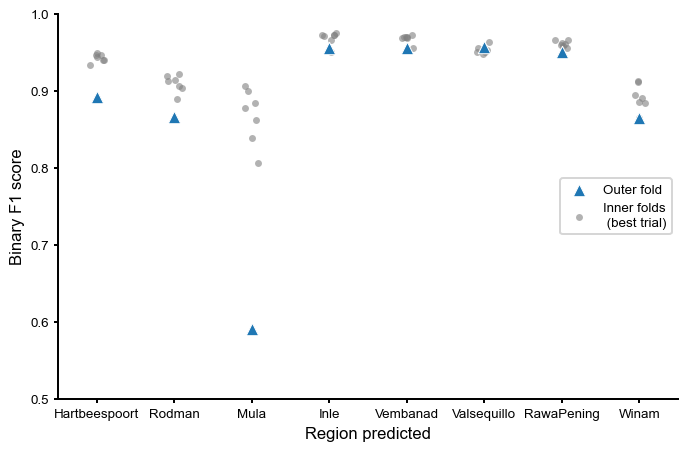

In [297]:
fig, ax = plt.subplots(figsize = (8,5))


set_pubr_theme(legend= "left")

sns.scatterplot(data = outer_cnn_15px_NO_AWEI, ax = ax, x = "test_region", y = "test_f1", label = "Outer fold", marker = "^", s = 80, zorder = 2)
sns.stripplot(data = inner_cnn_15px_NO_AWEI, ax = ax, x = "val_region", y = "val_f1", label = "Inner folds\n (best trial)", alpha = 0.6, color = "gray", zorder = 1)
ax.set_xlabel("Region predicted")
ax.set_ylabel("Binary F1 score")

ax.legend(loc = "lower right")
ax.set_ylim(bottom = 0.5, top = 1)
 
# Deduplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # keeps only the last handle per unique label
ax.legend(by_label.values(), by_label.keys(), loc = "right", frameon = True)



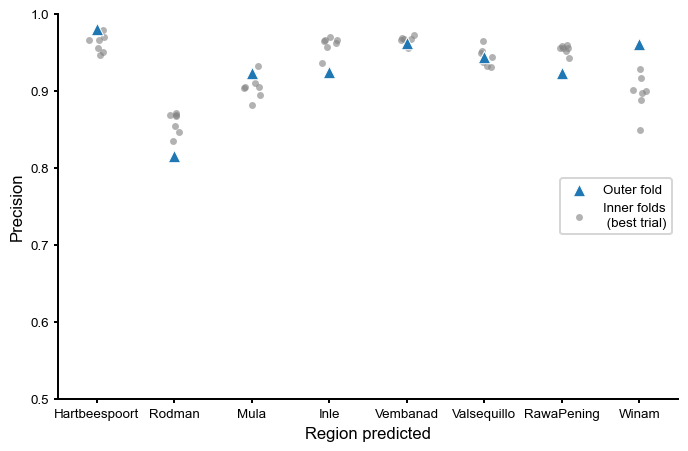

In [299]:
fig, ax = plt.subplots(figsize = (8,5))


set_pubr_theme(legend= "left")

sns.scatterplot(data = outer_cnn_15px_NO_AWEI, ax = ax, x = "test_region", y = "test_precision", label = "Outer fold", marker = "^", s = 80, zorder = 2)
sns.stripplot(data = inner_cnn_15px_NO_AWEI, ax = ax, x = "val_region", y = "val_precision", label = "Inner folds\n (best trial)", alpha = 0.6, color = "gray", zorder = 1)
ax.set_xlabel("Region predicted")
ax.set_ylabel("Precision")

ax.legend(loc = "lower right")
ax.set_ylim(bottom = 0.5, top = 1)
 
# Deduplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # keeps only the last handle per unique label
ax.legend(by_label.values(), by_label.keys(), loc = "right", frameon = True)

In [112]:

outer_df = outer_cnn_15px_NO_AWEI
inner_df = inner_cnn_15px_NO_AWEI
model = None
text_size = 20

metrics = ["f1", "accuracy","precision","recall"]
metric_name = ["Binary F1 Score", "Accuracy", "Precision", "Recall"]
palette = sns.color_palette("Set2", n_colors = 4)

AWEIp95 = outer_df["AWEIp95"][0]
patch_size = outer_df["patch_size"][0]

set_pubr_theme(base_size = 16)
fig, axes = plt.subplots(2,2, figsize = (16, 12))
axes = axes.flatten()

for ax, metric, name, color in zip(axes, metrics, metric_name, palette):
    sns.scatterplot(data = outer_df, ax = ax, x = "test_region", y = f"test_{metric}", color = color, edgecolor = "black", label = "Outer fold", marker = "^", s = 200, zorder = 2)
    sns.stripplot(data = inner_df, ax = ax, x = "val_region", y = f"val_{metric}", label = "Inner folds\n (best trial)", alpha = 0.5, color = "gray",s = 8, zorder = 1)
    ax.set_xlabel("")
    ax.set_ylabel(f"{name}")
    ax.set_title(f"{name}")
    fig.suptitle("Per Region Model Performance for Predicting Floating Plant Class", y = 1.04)
    if AWEIp95:
        if model:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, {model}, with AWEIp95 feature")
        else:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, with AWEIp95 feature")
    else:
        if model:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, {model}, no AWEIp95 feature")
        else:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, no AWEIp95 feature")
    ax.legend(loc = "lower right")
    ax.set_ylim(bottom = 0.4, top = 1)
    ax.tick_params(axis="x", rotation=45)
    
    # Deduplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))  # keeps only the last handle per unique label
    ax.legend(by_label.values(), by_label.keys(), loc = "lower right", frameon = True, borderpad = 0.9, labelspacing = 0.7)
    plt.tight_layout()

NameError: name 'outer_cnn_15px_NO_AWEI' is not defined

### Comparing across models
Per-region model perfomance plotted for different models

In [189]:
# Dictionaries for labels, colours and markers

palette = sns.color_palette("Set2", 8)

label_dict ={
    "7_GAP_AWEI_False": "CNN GAP\n7px patch\nNo AWEIp95",
    "15_GAP_AWEI_False": "CNN GAP\n15px patch\nNo AWEIp95",
    "15_GAP_AWEI_True": "CNN GAP\n15px patch\nWith AWEIp95",
    "31_GAP_AWEI_False": "CNN GAP\n31px patch\nNo AWEIp95",
    "RF_NO_AWEIp95": "Random Forest\nNo AWEIp95",
    "RF_WITH_AWEIp95": "Random Forest\nWith AWEIp95",
    "15_DENSE_AWEI_False": "CNN Dense\n15px patch\nNO AWEIp95",
    "31_DENSE_AWEI_False": "CNN Dense\n31px patch\nNO AWEIp95"
}

marker_styles = {
    "7_GAP_AWEI_False": {"colour": palette[0], "marker":"p"},
    "15_GAP_AWEI_False": {"colour": palette[1], "marker":"s"},
    "15_GAP_AWEI_True": {"colour": palette[2], "marker":"d"},
    "31_GAP_AWEI_False": {"colour": palette[3], "marker":"H"},
    "RF_NO_AWEIp95": {"colour": palette[4], "marker":"P"},
    "RF_WITH_AWEIp95": {"colour": palette[5], "marker":"X"},
    "15_DENSE_AWEI_False": {"colour": palette[6], "marker":"v"},
    "31_DENSE_AWEI_False": {"colour": palette[7], "marker":"^"}
}


In [111]:
# Rename RF xolumn, add a model column
rf_fp1 = PROJECT_ROOT / "outputs/RF_outputs"/ "RF_AWEI_False_outer_results.csv"

RF_NO_AWEI = pd.read_csv(rf_fp1, index_col = 0)
RF_NO_AWEI["model"] = "RF_NO_AWEIp95"
RF_NO_AWEI.rename(columns = {"test_location":"test_region"}, inplace = True)

rf_fp2 = PROJECT_ROOT / "outputs/RF_outputs"/ "RF_AWEI_True_outer_results.csv"

RF_WITH_AWEI = pd.read_csv(rf_fp2, index_col = 0)
RF_WITH_AWEI["model"] = "RF_WITH_AWEIp95"
RF_WITH_AWEI.rename(columns = {"test_location":"test_region"}, inplace = True)

RF_NO_AWEI

,test_region,test_f1,test_f1_macro,test_accuracy,test_precision,test_recall,test_auroc,best_n_estimators,best_max_depth,best_min_samples_leaf,train_f1,train_f1_macro,train_accuracy,f1_gap,f1_macro_gap,accuracy_gap,AWEIp95,model
0,Hartbeespoort,0.952138,0.953688,0.953740,0.971933,0.933134,0.953460,200,5,1,0.933213,0.932246,0.932260,-0.018926,-0.021442,-0.021480,False,RF_NO_AWEIp95
1,Inle,0.912349,0.909404,0.909500,0.884507,0.942000,0.909500,200,5,1,0.938631,0.937611,0.937628,0.026282,0.028207,0.028128,False,RF_NO_AWEIp95
2,Mula,0.837867,0.854320,0.856178,0.922156,0.767697,0.853446,100,10,1,0.972920,0.972798,0.972799,0.135052,0.118479,0.116621,False,RF_NO_AWEIp95
3,RawaPening,0.945219,0.945054,0.945055,0.943340,0.947106,0.945053,500,10,5,0.958468,0.958271,0.958272,0.013249,0.013216,0.013217,False,RF_NO_AWEIp95
4,Rodman,0.882327,0.865083,0.867287,0.793130,0.994129,0.867163,200,5,1,0.941185,0.940474,0.940482,0.058857,0.075391,0.073195,False,RF_NO_AWEIp95
5,Valsequillo,0.945721,0.945588,0.945588,0.943415,0.948039,0.945588,100,5,1,0.934372,0.933914,0.933918,-0.011349,-0.011673,-0.011671,False,RF_NO_AWEIp95
6,Vembanad,0.927146,0.927073,0.927073,0.927146,0.927146,0.927073,200,5,5,0.935083,0.934079,0.934095,0.007937,0.007006,0.007022,False,RF_NO_AWEIp95
7,Winam,0.862134,0.853407,0.853927,0.816637,0.913000,0.853897,500,5,5,0.942218,0.941571,0.941579,0.080084,0.088164,0.087652,False,RF_NO_AWEIp95


In [ ]:
# Do this by combining the outer dfs into long so can filter. 

# then can do a group_by(model, patch_size) or just filter
fp1 = PROJECT_ROOT / "outputs/CNN_outputs" / "15px_patch_size_NO_AWEI" / "Outer_fold_metrics_15px_smoothed_val_2026-07-25_NO_AWEI.csv"
fp2 = PROJECT_ROOT / "outputs/CNN_outputs" / "15px_patch_size_WITH_AWEI" / "Outer_fold_metrics_15px_smoothed_val_2026-07-27_WITH_AWEI.csv"
fp3 = PROJECT_ROOT / "outputs/CNN_outputs" / "31px_patch_size_NO_AWEI" / "Outer_fold_metrics_31px_smoothed_val_2026-07-26_NO_AWEI.csv"
fp4 = PROJECT_ROOT / "outputs/CNN_outputs" / "7px_patch_size_NO_AWEI" / "Outer_fold_metrics_7px_smoothed_val_2026-07-26_NO_AWEI.csv"

outer1 = pd.read_csv(fp1)
outer3 = pd.read_csv(fp3)
outer4 = pd.read_csv(fp4)
outer2 = pd.read_csv(fp2)

combined_outer_folds = pd.concat([outer4, outer1, outer3, outer2], ignore_index = True)
combined_outer_folds["model"] = combined_outer_folds["patch_size"].astype(str) + "_GAP" + "_AWEI_" + combined_outer_folds["AWEIp95"].astype(str)
combined_outer_folds = pd.concat([RF_NO_AWEI, RF_WITH_AWEI, combined_outer_folds], ignore_index = True)

combined_outer_folds["f1_gap"] = combined_outer_folds["train_f1"] - combined_outer_folds["test_f1"]

In [20]:
# Add in the CNN models with a Dense head

fp5 = PROJECT_ROOT / "outputs/CNN_outputs" / "15px_DENSE_patch_size_NO_AWEI" / "Outer_fold_metrics_15px_Dense_smoothed_val_2026-07-28_NO_AWEI.csv"
fp6 = PROJECT_ROOT / "outputs/CNN_outputs" / "31px_DENSE_patch_size_NO_AWEI" / "Outer_fold_metrics_31px_Dense_smoothed_val_2026-07-29_NO_AWEI.csv"


outer5 = pd.read_csv(fp5)
outer6 = pd.read_csv(fp6)

combined_outer_dense = pd.concat([outer5,outer6], ignore_index = True)
combined_outer_dense["model"] = combined_outer_dense["patch_size"].astype(str) + "_DENSE_" + "AWEI_" + combined_outer_dense["AWEIp95"].astype(str)
combined_outer_dense = pd.concat([combined_outer_dense, RF_NO_AWEI, RF_WITH_AWEI], ignore_index = True)

combined_outer_dense["f1_gap"] = combined_outer_dense["train_f1"] - combined_outer_dense["test_f1"]

combined_outer_folds_2 = pd.concat([combined_outer_folds, combined_outer_dense], ignore_index= True)


In [16]:
combined_outer_folds_2.columns

Index(['test_region', 'test_f1', 'test_f1_macro', 'test_accuracy',
       'test_precision', 'test_recall', 'test_auroc', 'best_n_estimators',
       'best_max_depth', 'best_min_samples_leaf', 'train_f1', 'train_f1_macro',
       'train_accuracy', 'f1_gap', 'f1_macro_gap', 'accuracy_gap', 'AWEIp95',
       'model', 'Unnamed: 0', 'run_ID', 'patch_size', 'epochs_trained', 'k',
       'test_loss', 'train_loss', 'train_precision', 'train_recall',
       'train_auroc', 'dropout', 'lr', 'weight_decay', 'batch_size'],
      dtype='object')

Could do, plt with the inner and outer, comparing models, 
Could do plot with each model as a category on the x axid and the y axis is box or violin plot of fold metrics

/var/folders/px/ysdd4tvd6z7255np16x_10l80000gn/T/ipykernel_94741/3081600279.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_dict.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])


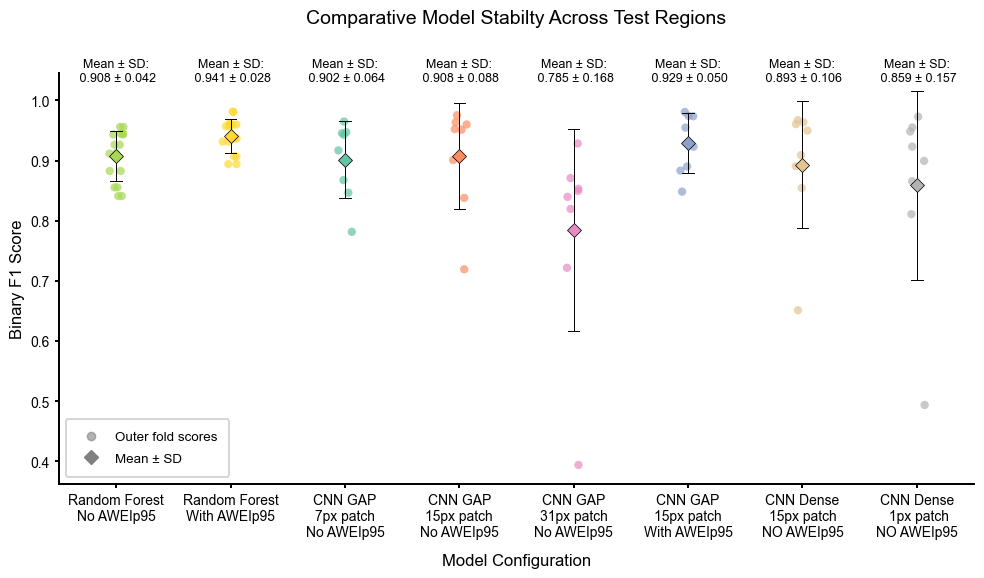

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D


present_models = combined_outer_folds_2['model'].unique()
model_palette   = {m: marker_styles[m]["colour"]  for m in present_models}
markers   = [marker_styles[m]["marker"] for m in present_models]



fig, ax = plt.subplots(figsize=(10, 6))

# raw points, jittered so they don't overlap
sns.stripplot(data=combined_outer_folds_2, x='model', y='test_f1', hue='model', zorder = 1,
              dodge=False, alpha=0.7, jitter=0.07, size=6, legend=False, ax = ax, palette= model_palette)

# mean ± SD on top
sns.pointplot(data=combined_outer_folds_2, x='model', y='test_f1', hue='model', estimator = 'mean', zorder = 3,
               linestyle = None, markers='D', linewidth=0.7, markersize = 7,
              errorbar='sd',err_kws={'color': 'black', "zorder": 2}, capsize=0.1, ax = ax, palette= model_palette, markeredgecolor = "black")

for i, model in enumerate(combined_outer_folds_2['model'].unique()):
    vals = combined_outer_folds_2.loc[combined_outer_folds_2['model'] == model, 'test_f1']
    mean, sd = vals.mean(), vals.std()
    plt.text(i, 1.07, f'Mean ± SD:\n {mean:.3f} ± {sd:.3f}',
             ha='center', va='top', fontsize=9)

ax.set_xticklabels([label_dict.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])

legend_elements = [
    Line2D([0], [0], marker='o', color='grey', linestyle='None',
           markersize=6, alpha=0.6, label='Outer fold scores'),
    Line2D([0], [0], marker='D', color='grey', linestyle='None',
           markersize=7, label='Mean ± SD'),
]

ax.legend(handles=legend_elements,loc='best',frameon = True, borderpad = 0.9, labelspacing = 0.7)


plt.xlabel("Model Configuration", labelpad= 10)
plt.title("Comparative Model Stabilty Across Test Regions", x= 0.5, y=1.1)
plt.ylabel('Binary F1 Score')
plt.tight_layout()



plt.show()


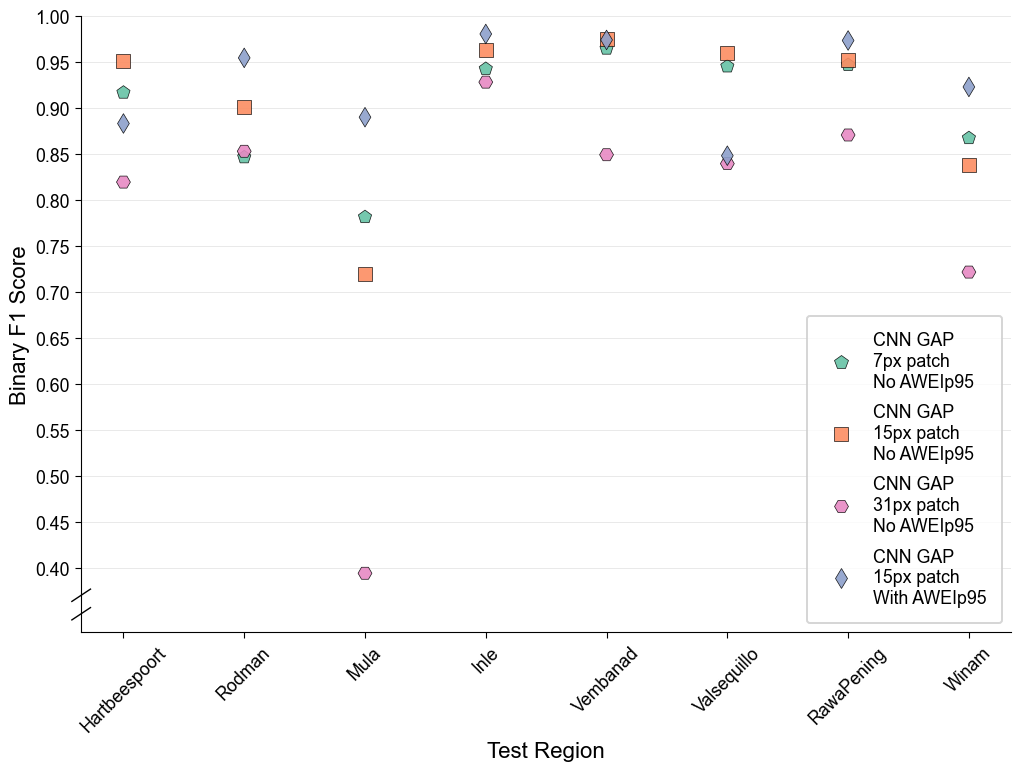

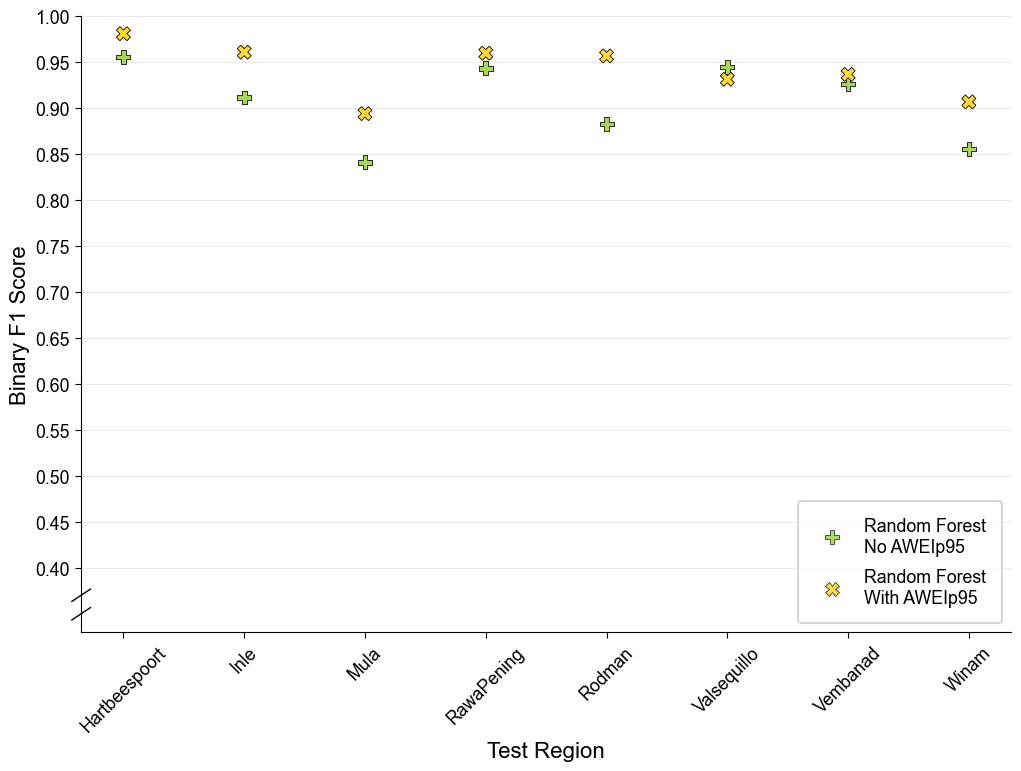

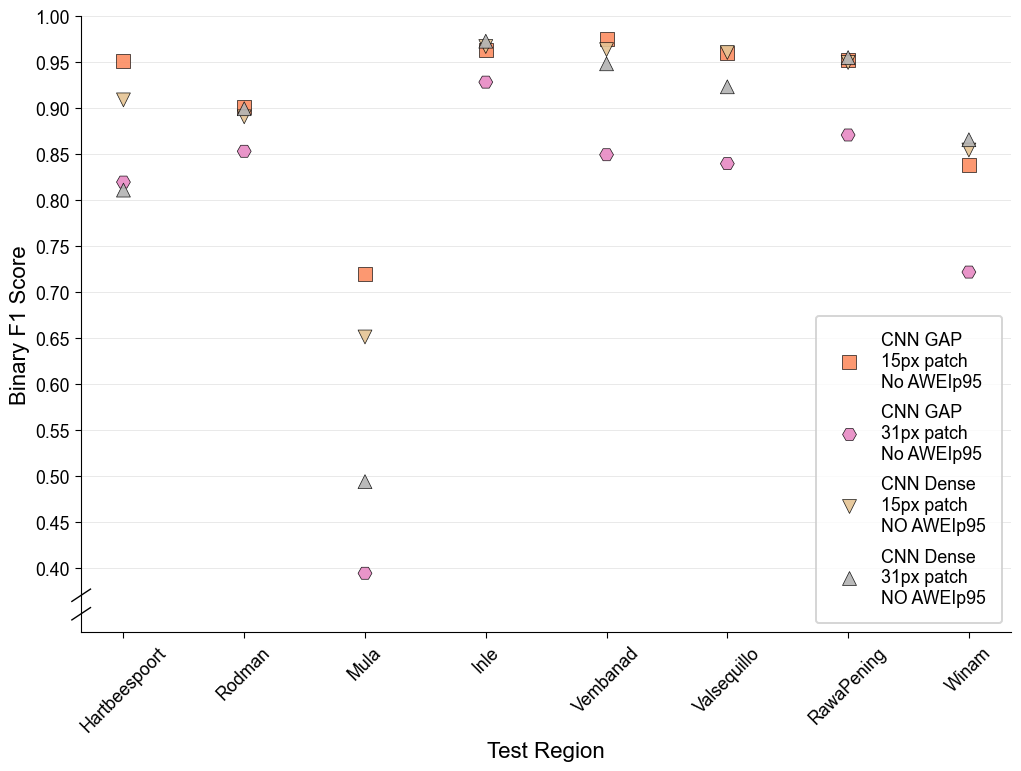

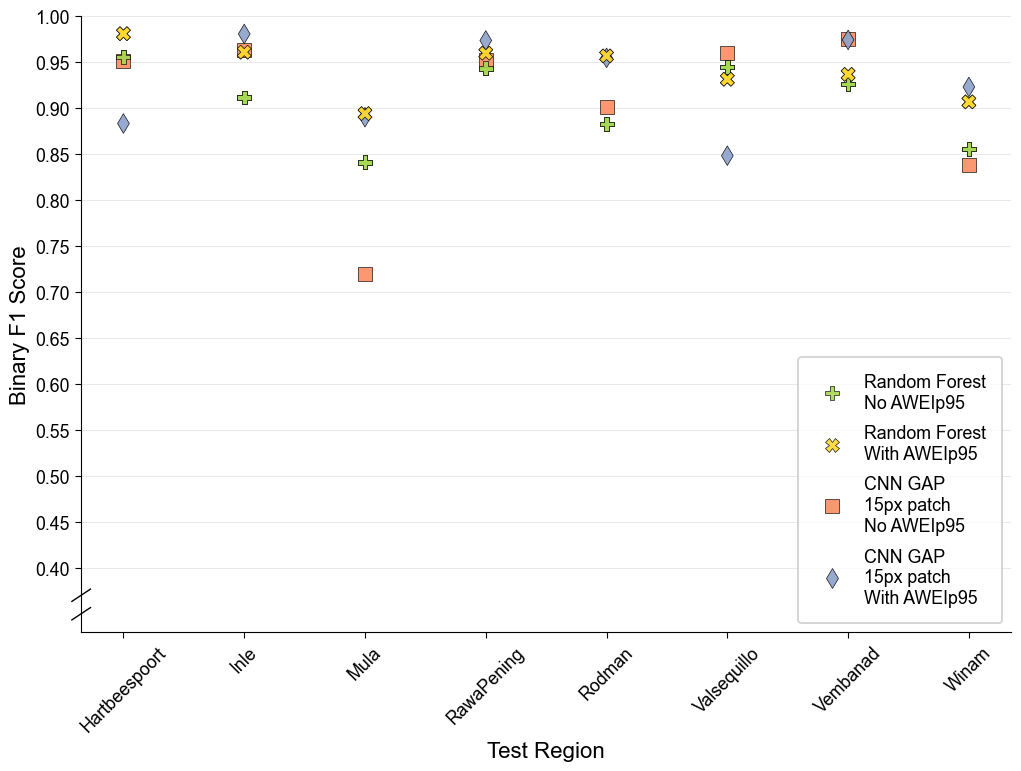

In [191]:
def plot_model_test_region_comparison(df, model_list = None, metric = "test_f1", title = None, marker_styles = marker_styles):

    if not model_list:
        model_list = ["RF_NO_AWEIp95", "RF_WITH_AWEIp95","7_GAP_AWEI_False", "15_GAP_AWEI_False", "31_GAP_AWEI_False", "15_GAP_AWEI_True", '15_DENSE_AWEI_False', "31_DENSE_AWEI_False"]

    subset_df = df.loc[combined_outer_folds_2["model"].isin(model_list)]

    present_models = subset_df['model'].unique()
    model_palette   = {m: marker_styles[m]["colour"]  for m in present_models}
    markers   = [marker_styles[m]["marker"] for m in present_models]

    fig,ax = plt.subplots(figsize=(12,8))
    sns.scatterplot(data = subset_df, x = "test_region", y = metric, style = "model", hue = "model", edgecolor="black", linewidth = 0.5, s = 100, palette = model_palette, markers=markers, alpha = 0.9)
    plt.legend(loc = "lower right", frameon = True, borderpad = 0.9, labelspacing = 0.7)
    plt.tick_params(axis = "x", rotation = 45)
    ax.set_title(title)
    ax.set_xlabel("Test Region")
    ax.set_ylabel("Binary F1 Score")
    ax.set_ylim(bottom= 0.33, top =1)
    ax.set_yticks(np.arange(0.4, 1.01, 0.05))
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="lightgray", linewidth=0.5, alpha=0.7)

    # --- zigzag break mark on the y-axis to flag non-zero origin ---
    d = 0.01  # size of the break mark, in axes-fraction units
    kwargs = dict(transform=ax.transAxes, color='k', clip_on=False, linewidth=1)
    # two small diagonal ticks stacked near the bottom of the y-axis spine
    ax.plot((-d, +d), (-d+0.06, +d+0.06), **kwargs)
    ax.plot((-d, +d), (-d + 0.03, +d + 0.03), **kwargs)
    
    # Remap legend labels
    legend = ax.get_legend()
    if legend:
        for text in legend.get_texts():
            text.set_text(label_dict.get(text.get_text(), text.get_text()))

    return fig

CNN_GAP = plot_model_test_region_comparison(df = combined_outer_folds_2, model_list = ["7_GAP_AWEI_False", "15_GAP_AWEI_False", "31_GAP_AWEI_False", "15_GAP_AWEI_True"], marker_styles= marker_styles)
RF = plot_model_test_region_comparison(df = combined_outer_folds_2, model_list = ["RF_NO_AWEIp95", "RF_WITH_AWEIp95"], marker_styles= marker_styles)
CNN_DENSE = plot_model_test_region_comparison(df = combined_outer_folds_2, model_list = ["15_GAP_AWEI_False", "31_GAP_AWEI_False", '15_DENSE_AWEI_False', "31_DENSE_AWEI_False"], marker_styles= marker_styles)
Best_four = plot_model_test_region_comparison(df = combined_outer_folds_2, model_list = [ "RF_NO_AWEIp95", "RF_WITH_AWEIp95","15_GAP_AWEI_False","15_GAP_AWEI_True",], marker_styles= marker_styles)



/var/folders/px/ysdd4tvd6z7255np16x_10l80000gn/T/ipykernel_79747/3729550203.py:4: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.scatterplot(data = combined_outer_folds, x = "test_region", y = "f1_gap", style = "model", hue = "model", edgecolor="black", linewidth = 0.5, s = 100, palette = palette)


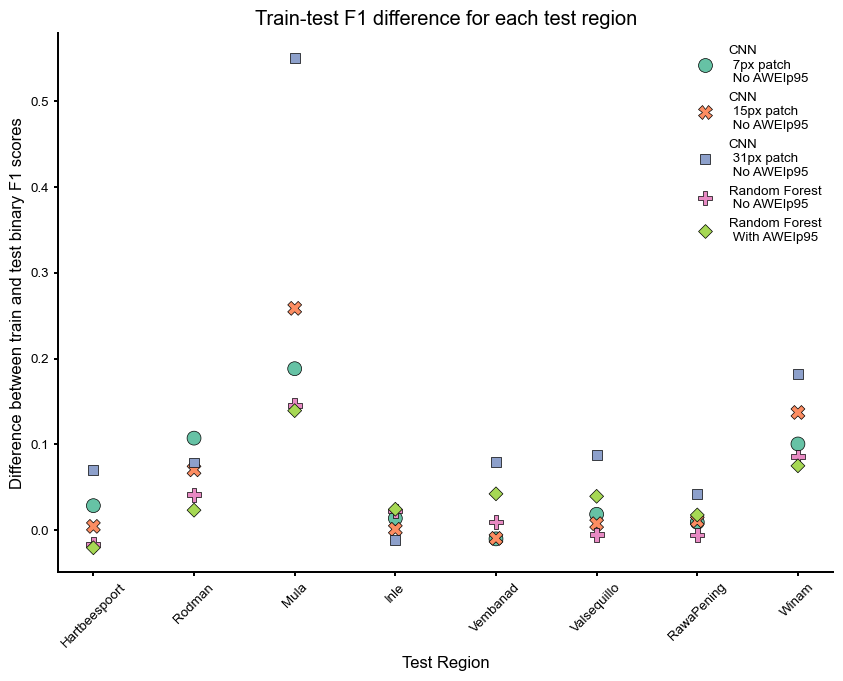

In [545]:
palette = sns.color_palette("Set2", 6)

fig,ax = plt.subplots(figsize=(10,7))
sns.scatterplot(data = combined_outer_folds, x = "test_region", y = "f1_gap", style = "model", hue = "model", edgecolor="black", linewidth = 0.5, s = 100, palette = palette)
plt.legend(loc = "upper right")
plt.tick_params(axis = "x", rotation = 45)
ax.set_title("Train-test F1 difference for each test region")
ax.set_xlabel("Test Region")
ax.set_ylabel("Difference between train and test binary F1 scores")

# Remap legend labels
legend = ax.get_legend()
if legend:
    for text in legend.get_texts():
        text.set_text(label_dict.get(text.get_text(), text.get_text()))

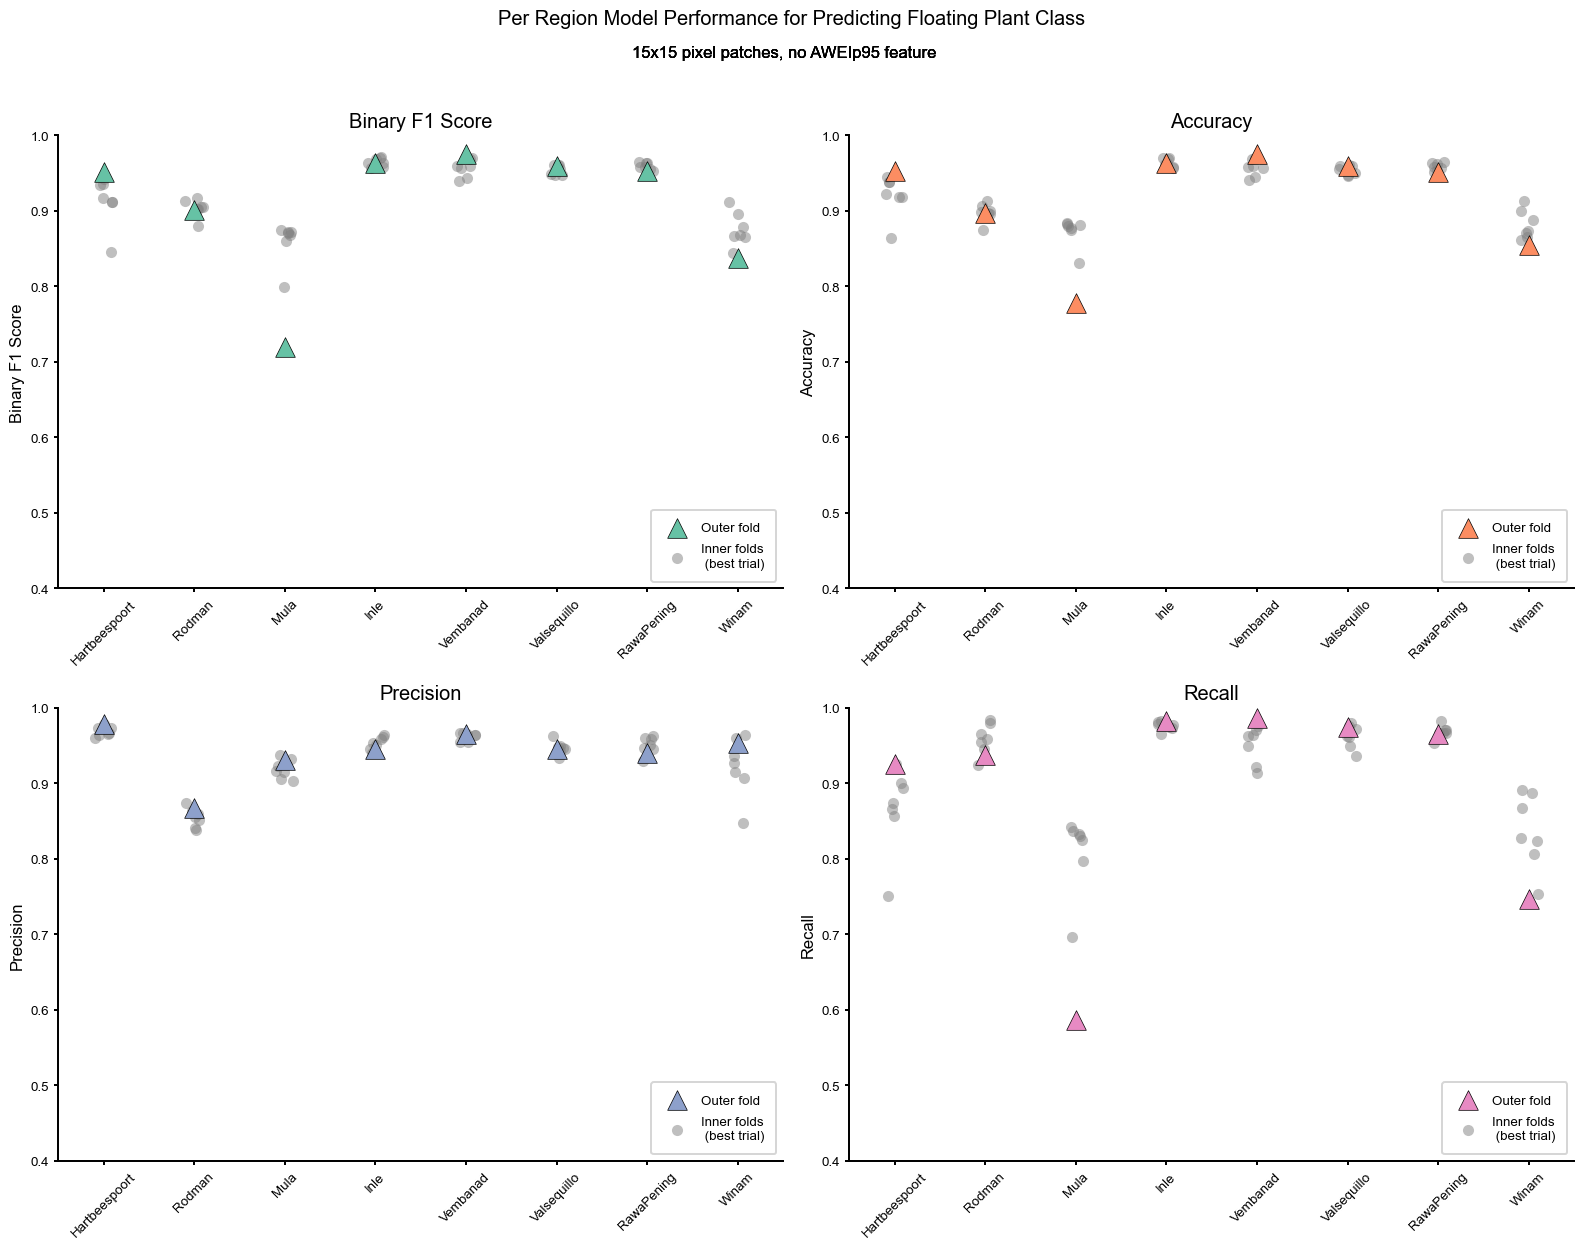

In [534]:
outer_fp = PROJECT_ROOT / "outputs/CNN_outputs" / "15px_patch_size_NO_AWEI" / "Outer_fold_metrics_15px_smoothed_val_2026-07-25_NO_AWEI.csv"
inner_fp = PROJECT_ROOT / "outputs/CNN_outputs" / "15px_patch_size_NO_AWEI" / "Inner_fold_best_state_metrics_15px_smoothed_val_2026-07-25_NO_AWEI.csv"

outer_df = pd.read_csv(outer_fp)
inner_df = pd.read_csv(inner_fp)
model = None
text_size = 20

metrics = ["f1", "accuracy","precision","recall"]
metric_name = ["Binary F1 Score", "Accuracy", "Precision", "Recall"]
palette = sns.color_palette("Set2", n_colors = 4)

AWEIp95 = outer_df["AWEIp95"][0]
patch_size = outer_df["patch_size"][0]

set_pubr_theme()
fig, axes = plt.subplots(2,2, figsize = (16, 12))
axes = axes.flatten()

for ax, metric, name, color in zip(axes, metrics, metric_name, palette):
    sns.scatterplot(data = outer_df, ax = ax, x = "test_region", y = f"test_{metric}", color = color, edgecolor = "black", label = "Outer fold", marker = "^", linewidth = 0.5, s = 200, zorder = 2)
    sns.stripplot(data = inner_df, ax = ax, x = "val_region", y = f"val_{metric}", label = "Inner folds\n (best trial)", alpha = 0.5, color = "gray",s = 8, zorder = 1)
    ax.set_xlabel("")
    ax.set_ylabel(f"{name}")
    ax.set_title(f"{name}")
    fig.suptitle("Per Region Model Performance for Predicting Floating Plant Class", y = 1.04)
    if AWEIp95:
        if model:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, {model}, with AWEIp95 feature")
        else:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, with AWEIp95 feature")
    else:
        if model:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, {model}, no AWEIp95 feature")
        else:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, no AWEIp95 feature")
    ax.legend(loc = "lower right")
    ax.set_ylim(bottom = 0.4, top = 1)
    ax.tick_params(axis="x", rotation=45)
    
    # Deduplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))  # keeps only the last handle per unique label
    ax.legend(by_label.values(), by_label.keys(), loc = "lower right", frameon = True, borderpad = 0.9, labelspacing = 0.7)
    plt.tight_layout()

### Loss curves

In [108]:
def plot_loss_curves(df, test_region, val_region=None, fold="inner", facet=False, ax=None, model = None,  **theme_kwargs):
    """Plot training/validation loss curves from the concatenated history_dict dataframe.

    Three modes:
      - facet=True                : grid of train + val loss for every inner
                                    val_region of test_region
      - facet=False, fold="outer" : single train-loss curve for the outer fold
      - facet=False, fold="inner" : single train + val curve for
                                    test_region / val_region

    In the single-plot modes an existing ``ax`` may be passed to draw onto
    (e.g. for side-by-side figures); if omitted the function creates and
    shows its own figure. The axis (or flattened axes array in facet mode)
    is returned. ``ax`` is ignored when facet=True.
    """
    AWEIp95 = df["AWEIp95"][0]
    patch_size = df["patch_size"][0]
    smoothing_window = int(df["k"][0])

    test_regions = df["test_region"].unique()

    

    if AWEIp95:
        if model:
            subtitle_text = f"{patch_size}x{patch_size} pixel patches | {model} | Smoothing window: {smoothing_window} | With AWEIp95 feature"
        else:
            subtitle_text = f"{patch_size}x{patch_size} pixel patches | Smoothing window: {smoothing_window} | With AWEIp95 feature"
    else:
        if model:
            subtitle_text = f"{patch_size}x{patch_size} pixel patches | {model} | Smoothing window: {smoothing_window} | No AWEIp95 feature"
        else:
            subtitle_text = f"{patch_size}x{patch_size} pixel patches | Smoothing window: {smoothing_window} | No AWEIp95 feature"

    if test_region not in test_regions:
        raise ValueError(f"test_region must be one of {list(test_regions)}")
    
    ax_labels = ["a)", "b)", "c)", "d)", "e)", "f)", "g)", "h)"]
    set_pubr_theme(**theme_kwargs)

    if facet:
        # grid of inner folds for this test region
        val_regions = (
            df.loc[(df["test_region"] == test_region) & (df["loop"] == "inner"), "val_region"]
            .dropna()
            .unique()
        )
        n = len(val_regions)
        
        fig, axes = plt.subplots(4, 2, figsize=(14, 16))
        axes = axes.flatten()

        for ax, region, ax_label in zip(axes, val_regions, ax_labels):
            sub = df.loc[
                (df["test_region"] == test_region)
                & (df["val_region"] == region)
                & (df["loop"] == "inner")
            ]
            best_epoch = int(sub["best_epoch"].iloc[0])
            best_val_loss = sub.loc[sub["epoch"]== best_epoch, "smoothed_val_loss"].iloc[0]
            sub.plot(x="epoch", y="train_loss", ax=ax, ylim=(0, 0.8), label="Training Loss")
            sub.plot(x="epoch", y="val_loss", ax=ax, label="Validation Loss")
            sub.plot(x="epoch", y="smoothed_val_loss", ax=ax, label="Smoothed \nValidation Loss")
            ax.scatter(best_epoch, best_val_loss, color = 'purple', zorder = 3, label = "Best Epoch", s = 40, edgecolor = "none")
            ax.set_title(f"Inner fold | Val region: {region}")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Binary Cross Entropy Loss")
            ax.text(0.02, 0.98, ax_label, transform=ax.transAxes,
                    ha="left", va="top", fontweight="bold")
            ax.legend(loc = 'upper right', frameon = True, facecolor = 'white', framealpha = 1, edgecolor = "none")
            ax.grid(True, alpha=0.3)

        # final cell: outer fold train loss
        outer = df.loc[(df["test_region"] == test_region) & (df["loop"] == "outer")]
        ax = axes[n]
        outer.plot(x="epoch", y="train_loss", ax=ax, ylim=(0, 0.8), label="Training Loss")
        ax.set_title(f"Outer fold | Test region: {test_region}")
        ax.text(0.02, 0.98, ax_labels[n], transform=ax.transAxes,
                ha="left", va="top", fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Binary Cross Entropy Loss")
        ax.grid(True, alpha=0.3)

        # hide any axes still unused
        for ax in axes[n + 1:]:
            ax.set_visible(False)

        fig.suptitle(
            f"Training vs Validation Loss | Test region: {test_region}", y=1.02
        )
        fig.text(0.3, 0.99, subtitle_text)
        plt.tight_layout()
        # plt.show() commented out so that it doesnt close before i save, will call after returning the figure

        return fig

    else:
        if fold not in ["inner", "outer"]:
            raise ValueError('fold must be either "inner" or "outer"')

        created_fig = ax is None
        if created_fig:
            fig, ax = plt.subplots(figsize=(8, 6))

        if fold == "outer":
            sub = df.loc[(df["test_region"] == test_region) & (df["loop"] == "outer")]
            sub.plot(x="epoch", y="train_loss", ax=ax, ylim=(0, 0.8), label="Training Loss")
            ax.legend(loc = 'best', frameon = True, facecolor = 'white', framealpha = 1, edgecolor = "none")
            if created_fig:
                fig.suptitle(f"Training and Validation Loss", y = 1.02)
                fig.text(0.2, 0.95, subtitle_text)
            ax.set_title(f"Outer Fold | Test region: {test_region}")

        else:  # inner
            val_regions = (
                df.loc[(df["test_region"] == test_region) & (df["loop"] == "inner"), "val_region"]
                .dropna()
                .unique()
            )
            if not val_region or val_region not in val_regions:
                raise ValueError(f"Please specify a val_region from {list(val_regions)}")
            sub = df.loc[
                (df["test_region"] == test_region)
                & (df["val_region"] == val_region)
                & (df["loop"] == "inner")
            ]
            best_epoch = int(sub["best_epoch"].iloc[0])
            best_val_loss = sub.loc[sub["epoch"]== best_epoch, "smoothed_val_loss"].iloc[0]
            sub.plot(x="epoch", y="train_loss", ax=ax, ylim=(0, 0.8), label="Training Loss")
            sub.plot(x="epoch", y="val_loss", ax=ax, label="Validation Loss")
            sub.plot(x="epoch", y="smoothed_val_loss", ax=ax, label="Smoothed \nValidation Loss")
            ax.scatter(best_epoch, best_val_loss, color = 'purple', zorder = 3, label = "Best Epoch", s = 40, edgecolor = "black")
            ax.legend(loc = 'best', frameon = True, facecolor = 'white', framealpha = 1, edgecolor = "none")
            if created_fig:
                fig.suptitle(f"Training and Validation Loss", y = 1.02)
                fig.text(0.2, 0.95, subtitle_text)
            ax.set_title(f"Inner Fold | Test region: {test_region} | Val region: {val_region}")

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Binary Cross Entropy Loss")
        ax.grid(True, alpha=0.3)

      
        # if created_fig:
        #     plt.show()

        return fig


In [79]:
history_fp ="/Users/bensutton/Projects/dissertation-code/outputs/CNN_outputs/15px_patch_size_NO_AWEI/training_run_history_15px_smoothed_val_2026-07-25_NO_AWEI.csv"
history = pd.read_csv(history_fp)

history

,Unnamed: 0,test_region,val_region,run_ID,patch_size,loop,epoch,train_loss,smoothed_val_loss,k,...,val_precision,val_recall,val_auroc,train_accuracy,train_f1,train_precision,train_recall,train_auroc,AWEIp95,best_epoch
0,0,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-25,15,inner,1,0.395551,0.617675,5.0,...,0.759150,0.629158,0.768849,0.820471,0.816935,0.829006,0.805210,0.903255,False,16.0
1,1,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-25,15,inner,2,0.287538,0.527311,5.0,...,0.827957,0.904110,0.901691,0.887247,0.886695,0.886548,0.886843,0.949534,False,16.0
2,2,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-25,15,inner,3,0.218356,0.477070,5.0,...,0.882040,0.812133,0.929285,0.922080,0.922112,0.917118,0.927161,0.969375,False,16.0
3,3,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-25,15,inner,4,0.207614,0.452511,5.0,...,0.863415,0.865949,0.925103,0.926372,0.926134,0.924450,0.927825,0.972392,False,16.0
4,4,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-25,15,inner,5,0.205266,0.477824,5.0,...,0.847744,0.882583,0.867955,0.925217,0.924651,0.926964,0.922349,0.973090,False,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1740,1740,Winam,NaN,Test_Win_outer_15px_2026-07-25,15,outer,30,0.079581,NaN,NaN,...,NaN,NaN,NaN,0.974560,0.974475,0.971658,0.977308,0.995378,False,NaN
1741,1741,Winam,NaN,Test_Win_outer_15px_2026-07-25,15,outer,31,0.076902,NaN,NaN,...,NaN,NaN,NaN,0.974207,0.974105,0.971905,0.976315,0.995971,False,NaN
1742,1742,Winam,NaN,Test_Win_outer_15px_2026-07-25,15,outer,32,0.077784,NaN,NaN,...,NaN,NaN,NaN,0.974137,0.974040,0.971634,0.976457,0.995801,False,NaN
1743,1743,Winam,NaN,Test_Win_outer_15px_2026-07-25,15,outer,33,0.077460,NaN,NaN,...,NaN,NaN,NaN,0.973855,0.973812,0.969365,0.978301,0.995738,False,NaN


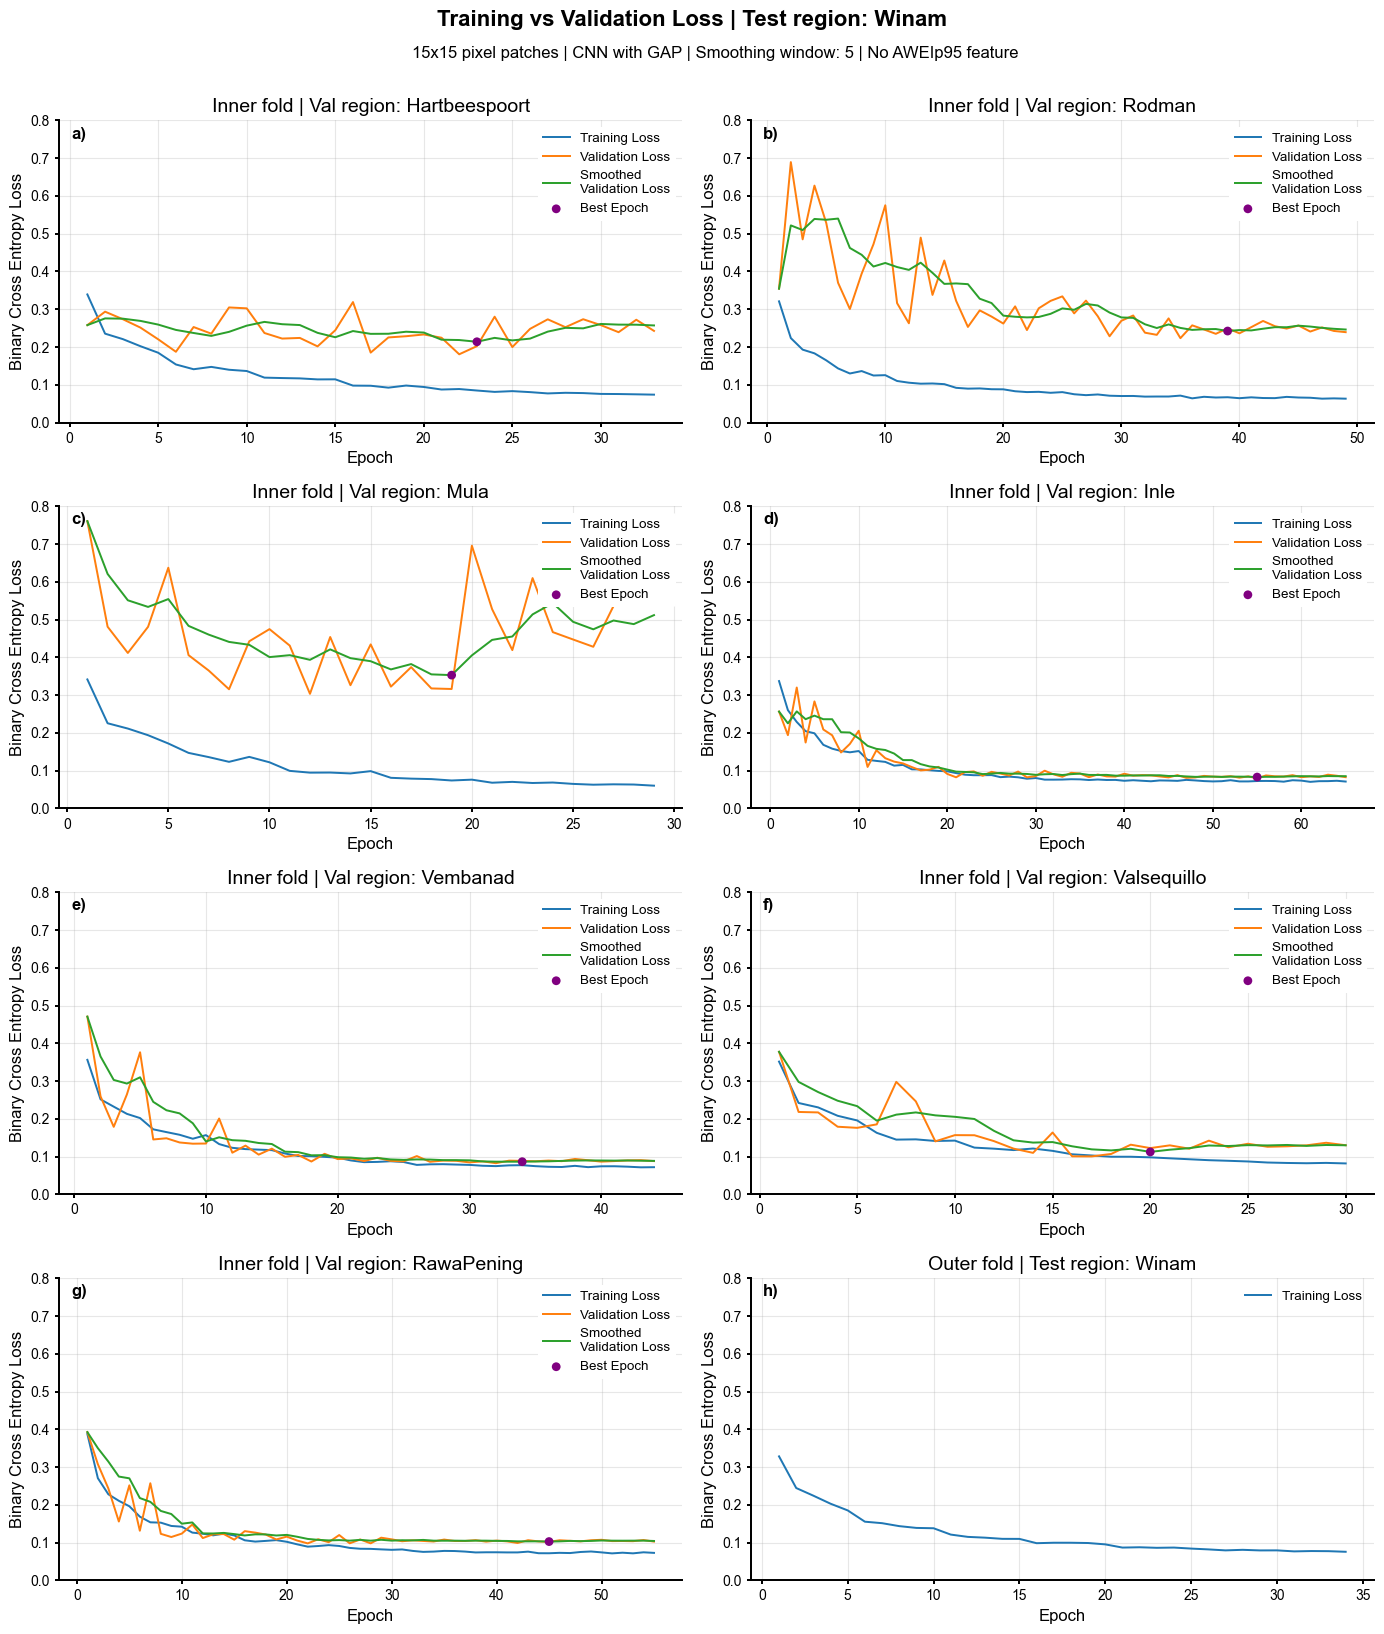

In [109]:
fig = plot_loss_curves(history, "Winam", facet = True, model = "CNN with GAP", axis_text_size = 10, axis_title_size = 12, title_size = 14, suptitle_size = 16 )
plt.show()
    # title_size=None,       # override panel title size (else 1.2 * base_size)
    # axis_title_size=None,  # override axis label size (else 1.0 * base_size)
    # axis_text_size=None,   # override tick label size (else 0.8 * base_size)
    # legend_txt_size=None,  # override legend text size (else 0.8 * base_size)
    # legend_ttl_size=None,  # override legend title size (else 1.0 * base_size)
    # suptitle_size=None,    # override figure suptitle size (else 1.2 * base_size)


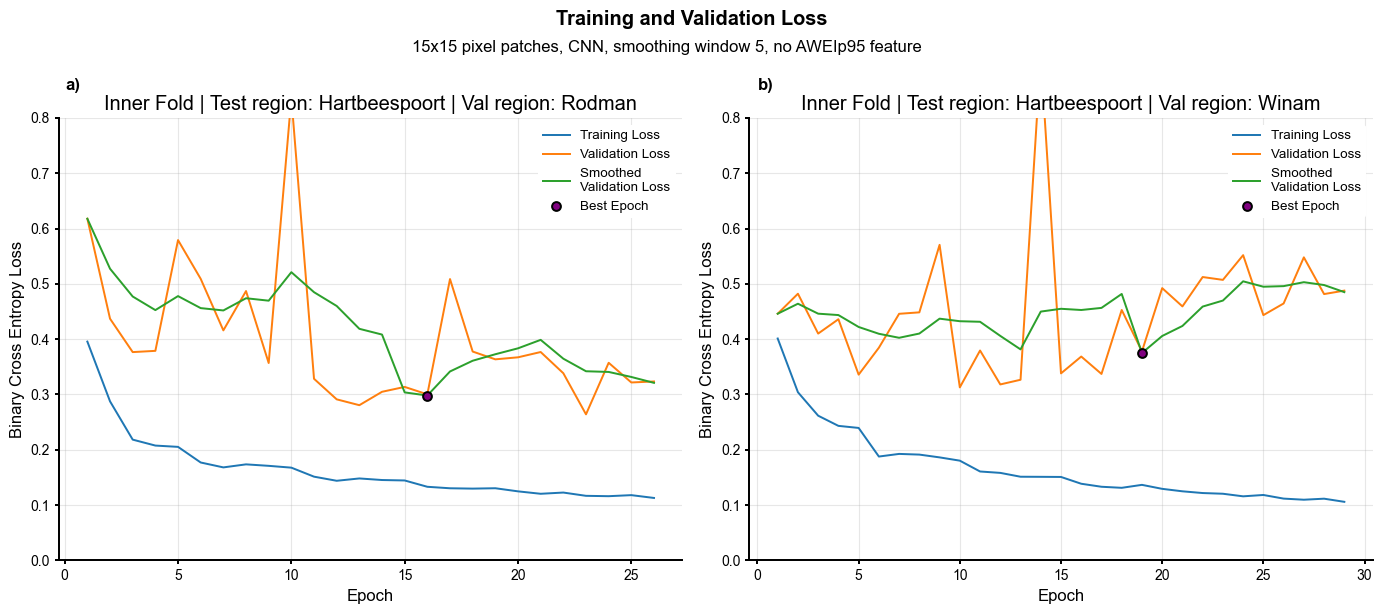

In [61]:
# Side by side loss curve comparison

df = history
left_test_region, left_val_region  = ("Hartbeespoort", "Rodman")
right_test_region, right_val_region = ("Hartbeespoort", "Winam")
fold = "inner"
model = "CNN"

patch_size = df["patch_size"][0]
AWEIp95 = df["AWEIp95"][0]
smoothing_window = int(df["k"][0])

if AWEIp95:
    if model:
        subtitle_text = f"{patch_size}x{patch_size} pixel patches, {model}, smoothing window {smoothing_window}, with AWEIp95 feature"
    else:
        subtitle_text = f"{patch_size}x{patch_size} pixel patches, smoothing window {smoothing_window}, with AWEIp95 feature"
else:
    if model:
        subtitle_text = f"{patch_size}x{patch_size} pixel patches, {model}, smoothing window {smoothing_window}, no AWEIp95 feature"
    else:
        subtitle_text = f"{patch_size}x{patch_size} pixel patches, smoothing window {smoothing_window}, no AWEIp95 feature"

# Get model info for subtitle 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_loss_curves(df, test_region = left_test_region, val_region = left_val_region,fold= fold, ax=axes[0])
plot_loss_curves(df, test_region = right_test_region, val_region= right_val_region, fold= fold, ax=axes[1])
fig.suptitle(f"Training and Validation Loss", y = 1.02)

axes[0].text(0.02, 0.85, "a)", fontweight = "bold")
axes[1].text(0.02, 0.85, "b)", fontweight = "bold")

fig.text(0.3, 0.95, subtitle_text)
plt.tight_layout()
plt.show()

In [114]:
fp5 = PROJECT_ROOT / "outputs/CNN_outputs" / "15px_DENSE_patch_size_NO_AWEI" / "training_run_history_15px_Dense_smoothed_val_2026-07-28_NO_AWEI.csv"
fp6 = PROJECT_ROOT / "outputs/CNN_outputs" / "31px_DENSE_patch_size_NO_AWEI" / "training_run_history_31px_Dense_smoothed_val_2026-07-29_NO_AWEI.csv"

history_fp_list = [fp5,fp6]

test_region = "Winam"
model = "CNN dense head"
for fp in history_fp_list:

    history_df = pd.read_csv(fp, )
    fig = plot_loss_curves(history_df, test_region, facet = True, model = model, axis_text_size = 10, axis_title_size = 12, title_size = 14, suptitle_size = 16 )

    patch_size = history_df["patch_size"][0]
    AWEIp95 = history_df["AWEIp95"][0]  

    save_string = f"Faceted_loss_curves_outer_{test_region}_{patch_size}_{model}_AWEI_{AWEIp95}"
    
    save_fp = PROJECT_ROOT / "outputs/plots" / f"{save_string}.png"

    fig.savefig(save_fp, dpi = 300, bbox_inches = "tight")
    plt.close(fig)

In [113]:
fp1 = PROJECT_ROOT / "outputs/CNN_outputs" / "15px_patch_size_NO_AWEI" / "training_run_history_15px_smoothed_val_2026-07-25_NO_AWEI.csv"
fp2 = PROJECT_ROOT / "outputs/CNN_outputs" / "15px_patch_size_WITH_AWEI" / "training_run_history_15px_smoothed_val_2026-07-27_WITH_AWEI.csv"
fp3 = PROJECT_ROOT / "outputs/CNN_outputs" / "31px_patch_size_NO_AWEI" / "training_run_history_31px_smoothed_val_2026-07-26_NO_AWEI.csv"
fp4 = PROJECT_ROOT / "outputs/CNN_outputs" / "7px_patch_size_NO_AWEI" / "training_run_history_7px_smoothed_val_2026-07-26_NO_AWEI.csv"


history_fp_list = [fp1,fp2,fp3,fp4]

test_region = "Winam"
model = "CNN with GAP"

for fp in history_fp_list:

    history_df = pd.read_csv(fp, )
    fig = plot_loss_curves(history_df, test_region, facet = True, model = model, axis_text_size = 10, axis_title_size = 12, title_size = 14, suptitle_size = 16 )

    patch_size = history_df["patch_size"][0]
    AWEIp95 = history_df["AWEIp95"][0]  

    save_string = f"Faceted_loss_curves_outer_{test_region}_{patch_size}_{model}_AWEI_{AWEIp95}"
    
    save_fp = PROJECT_ROOT / "outputs/plots" / f"{save_string}.png"

    fig.savefig(save_fp, dpi = 300, bbox_inches = "tight")
    plt.close(fig)
    
    

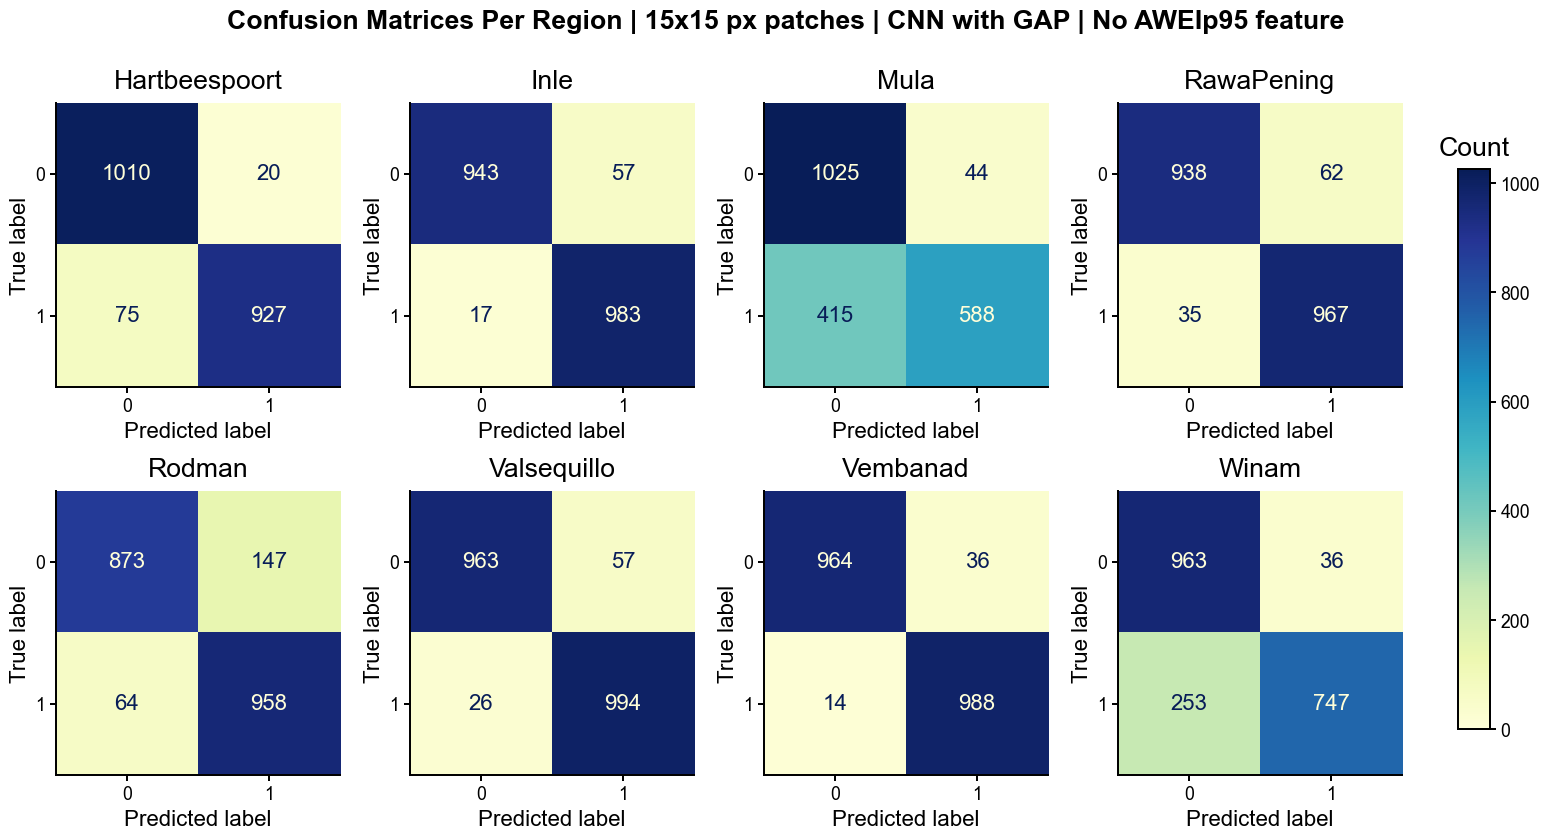

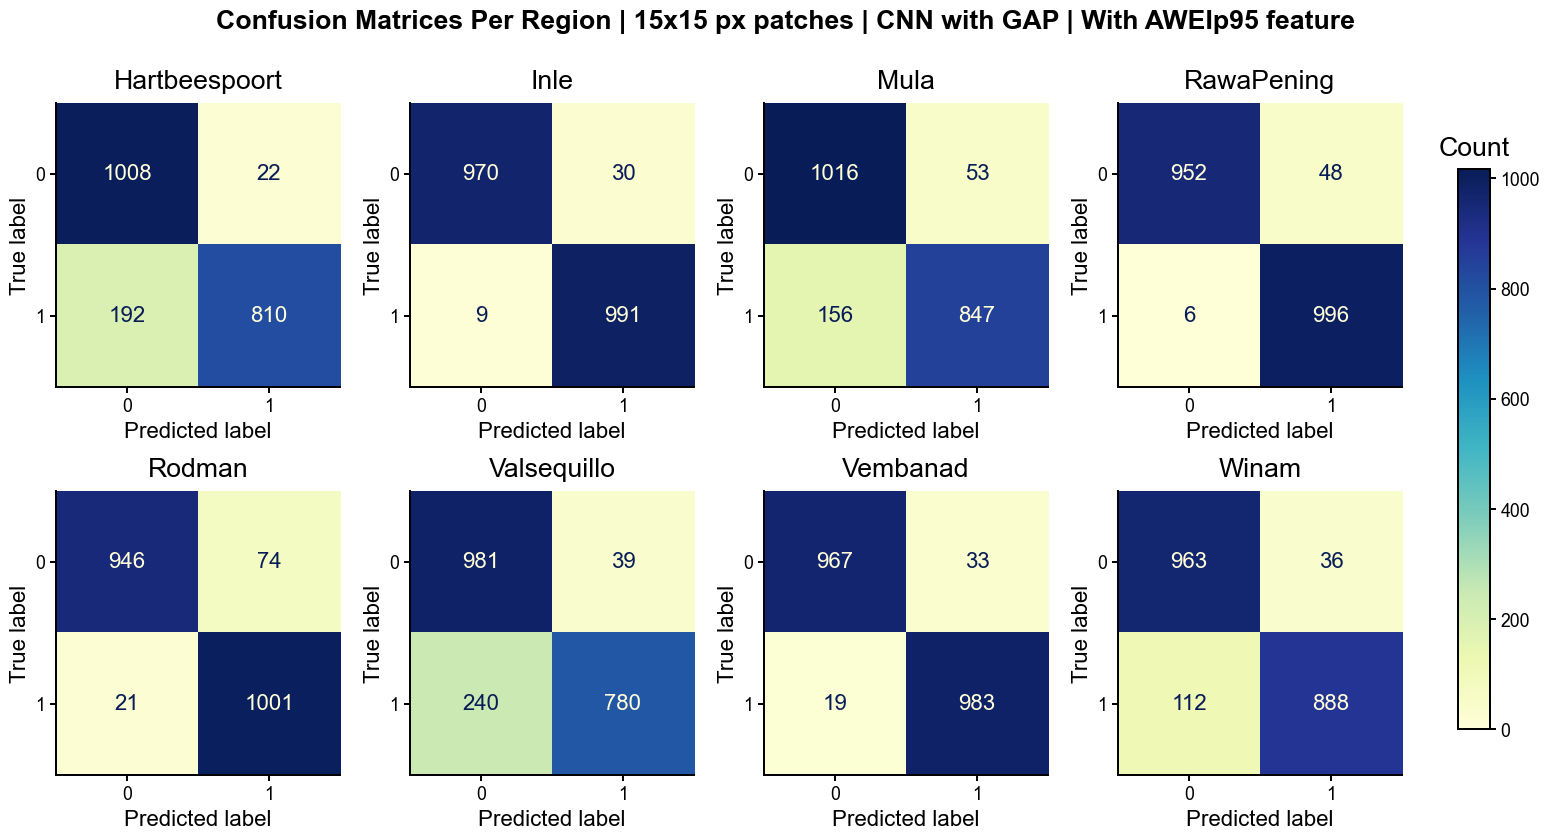

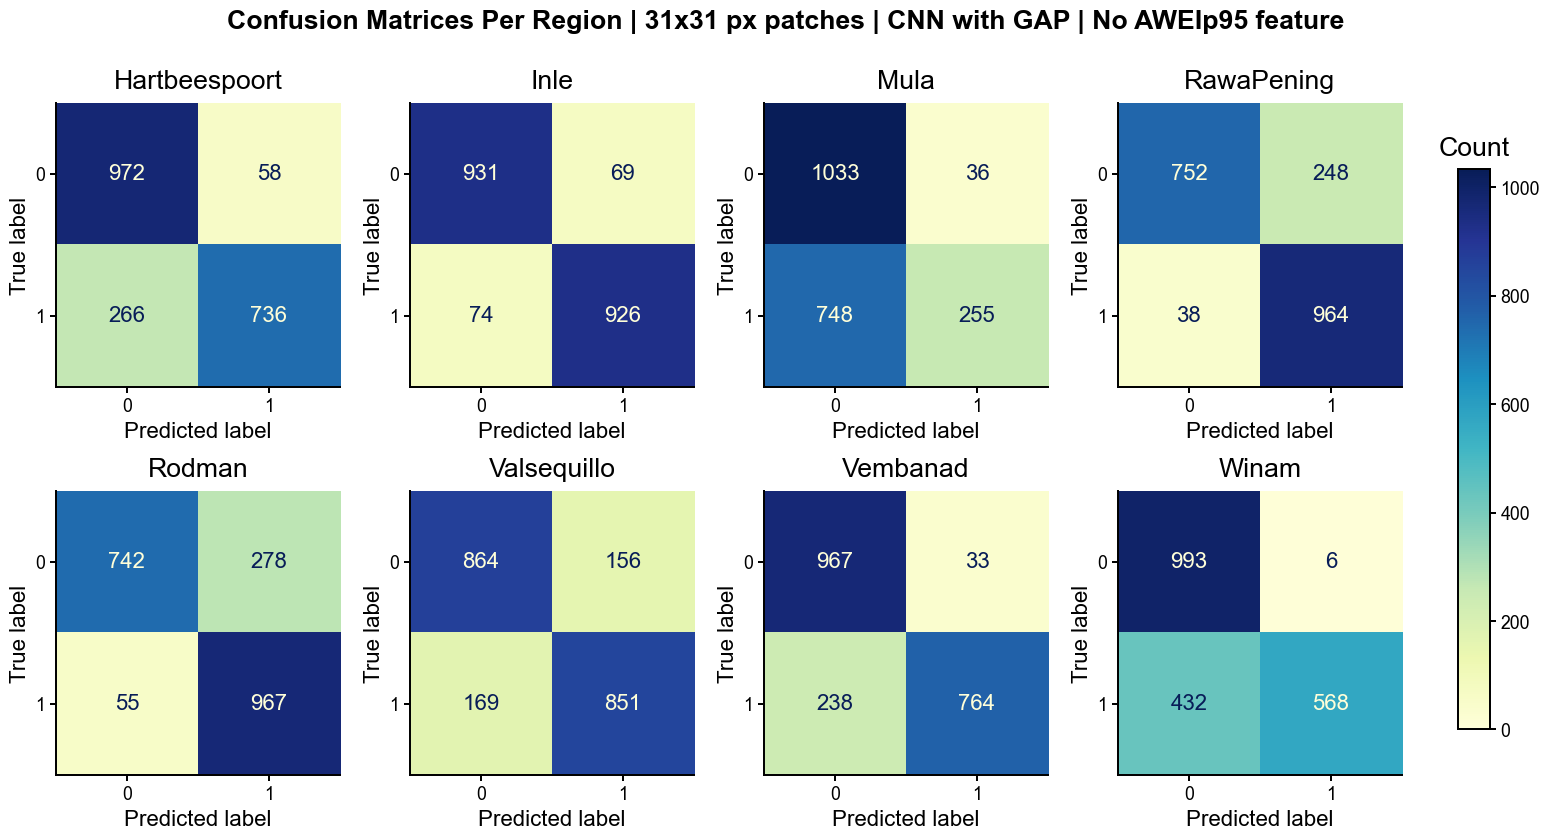

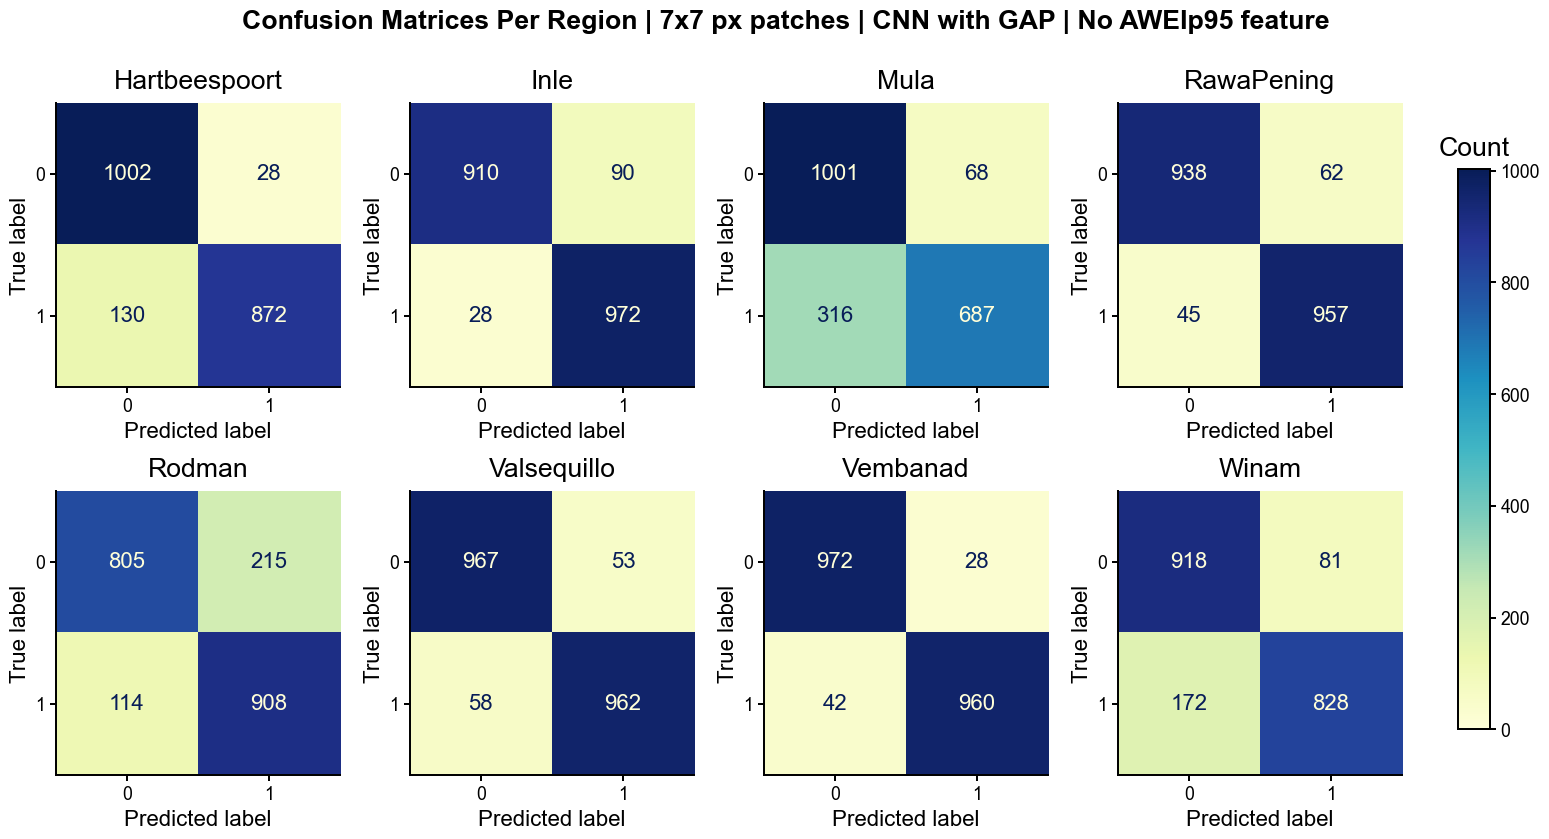

In [163]:
outer_predictions_fp = PROJECT_ROOT / "outputs" / "CNN_outputs" / "31px_patch_size_NO_AWEI" / "Outer_fold_predictions_31px_smoothed_val_2026-07-26_NO_AWEI.csv"

fp1 = PROJECT_ROOT / "outputs/CNN_outputs" / "15px_patch_size_NO_AWEI" / "Outer_fold_predictions_15px_smoothed_val_2026-07-25_NO_AWEI.csv"
fp2 = PROJECT_ROOT / "outputs/CNN_outputs" / "15px_patch_size_WITH_AWEI" / "Outer_fold_predictions_15px_smoothed_val_2026-07-27_WITH_AWEI.csv"
fp3 = PROJECT_ROOT / "outputs/CNN_outputs" / "31px_patch_size_NO_AWEI" / "Outer_fold_predictions_31px_smoothed_val_2026-07-26_NO_AWEI.csv"
fp4 = PROJECT_ROOT / "outputs/CNN_outputs" / "7px_patch_size_NO_AWEI" / "Outer_fold_predictions_7px_smoothed_val_2026-07-26_NO_AWEI.csv"


model = "CNN with GAP"


prediction_fp_list = [fp1,fp2,fp3,fp4]
patch_size_list = [15, 15, 31, 7] # didnt save a patch size to this csv!

for fp, patch_size in zip(prediction_fp_list, patch_size_list):

    predictions_df = pd.read_csv(fp)

    AWEIp95 = predictions_df["AWEI"][0]
    

    if AWEIp95:
        model_string = f"{patch_size}x{patch_size} px patches | {model} | With AWEIp95 feature"
    else:
        model_string = f"{patch_size}x{patch_size} px patches | {model} | No AWEIp95 feature"

    set_pubr_theme(
        base_size= 16
    )
   

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    # compute a shared color scale so the colorbar is meaningful across panels
    all_cms = []
    groups = list(predictions_df.groupby('test_region'))
    for _, group in groups:
        all_cms.append(confusion_matrix(group['labels'], group['predicted']))
    vmax = max(cm.max() for cm in all_cms)

    disp = None  # keep a reference to use for the colorbar
    for ax, (location, group), cm in zip(axes, groups, all_cms):
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
        disp.plot(ax=ax, cmap = "YlGnBu", colorbar=False, im_kw={'vmin': 0, 'vmax': vmax})
        ax.set_title(location, pad= 10)

    # leave room on the right for the shared colorbar
    fig.tight_layout(rect=[0, 0, 0.9, 1])

    # add one colorbar in a dedicated axes: [left, bottom, width, height] in figure coords
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(disp.im_, cax=cbar_ax)
    cbar_ax.set_title('Count', pad = 10)
    fig.suptitle(f"Confusion Matrices Per Region | {model_string}", y = 1.05)

    save_fp = PROJECT_ROOT / "outputs/plots" / "confusion_matrices" / f"Confusion_matrices_{model_string}.png"

    fig.savefig(save_fp, dpi= 300, bbox_inches = 'tight')
    plt.show()

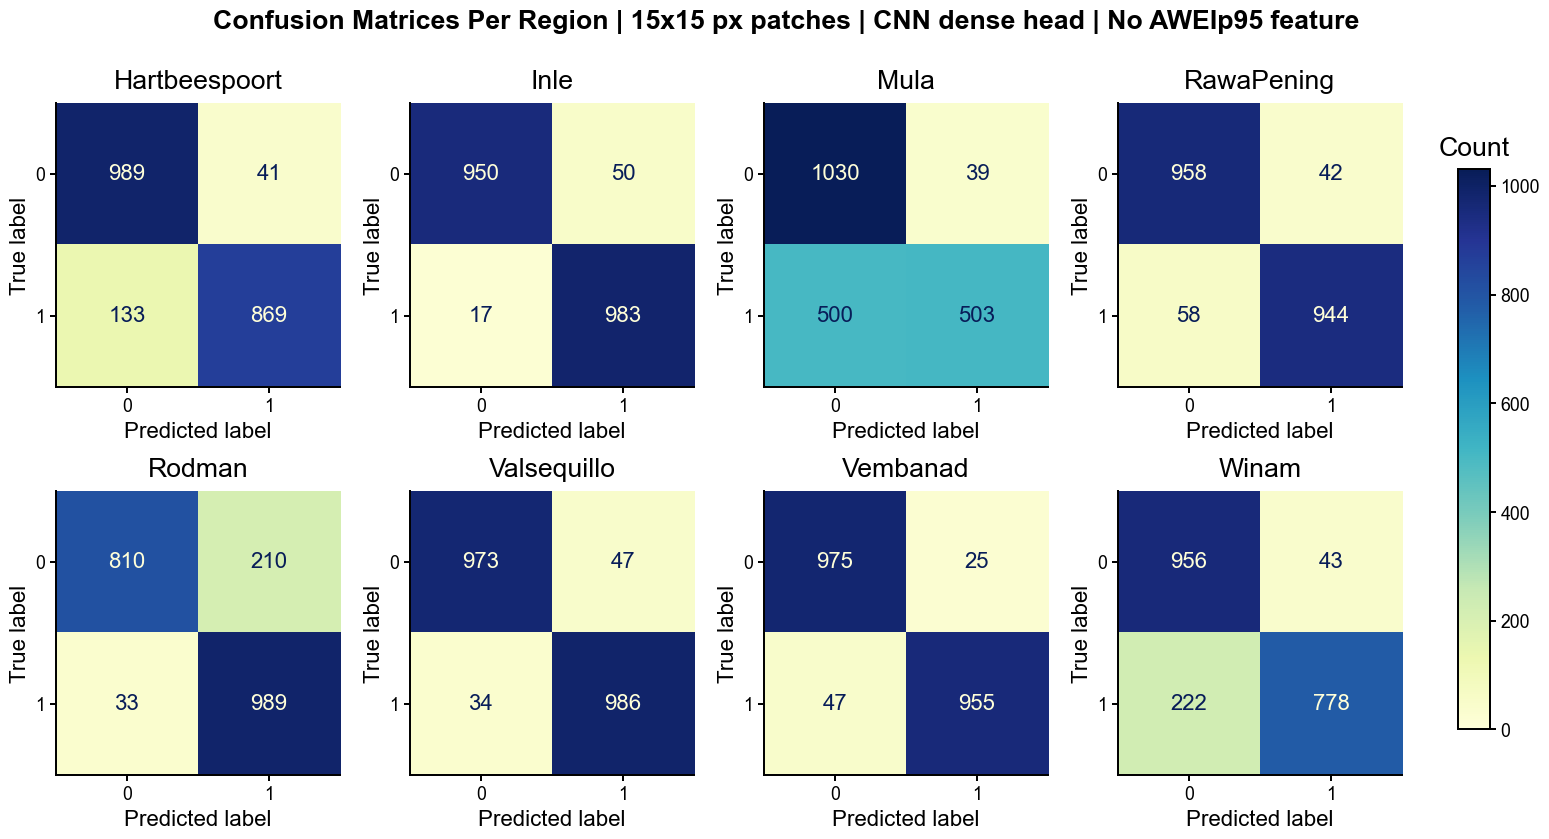

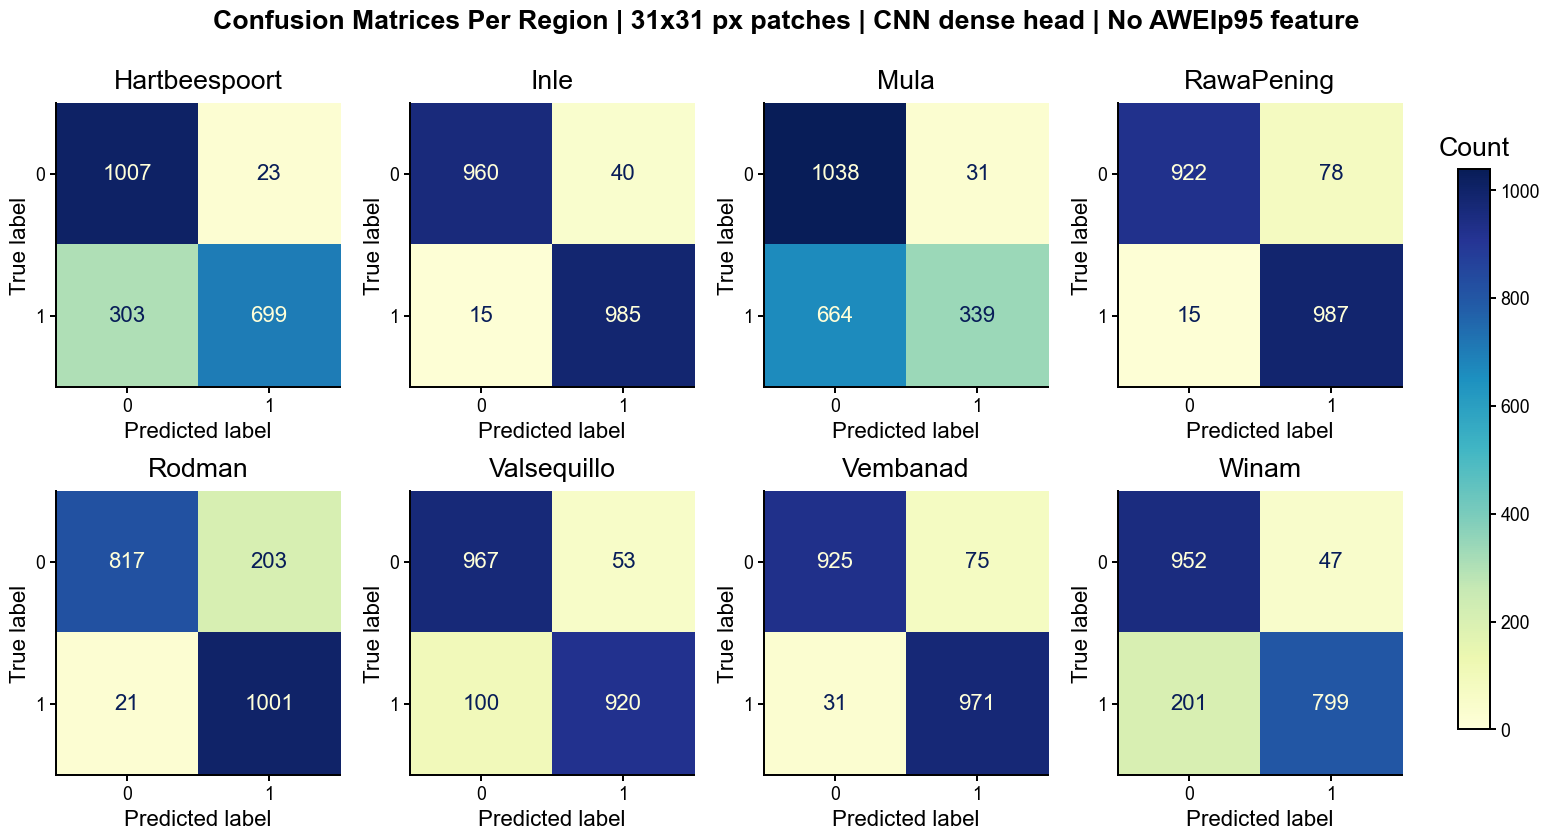

In [164]:
fp5 = PROJECT_ROOT / "outputs/CNN_outputs" / "15px_DENSE_patch_size_NO_AWEI" / "Outer_fold_predictions_15px_Dense_smoothed_val_2026-07-28_NO_AWEI.csv"
fp6 = PROJECT_ROOT / "outputs/CNN_outputs" / "31px_DENSE_patch_size_NO_AWEI" / "Outer_fold_predictions_31px_Dense_smoothed_val_2026-07-29_NO_AWEI.csv"

model = "CNN dense head"


prediction_fp_list = [fp5, fp6]
patch_size_list = [15, 31] # didnt save a patch size to this csv!

for fp, patch_size in zip(prediction_fp_list, patch_size_list):

    predictions_df = pd.read_csv(fp)

    AWEIp95 = predictions_df["AWEI"][0]
    

    if AWEIp95:
        model_string = f"{patch_size}x{patch_size} px patches | {model} | With AWEIp95 feature"
    else:
        model_string = f"{patch_size}x{patch_size} px patches | {model} | No AWEIp95 feature"

    set_pubr_theme(
        base_size= 16
    )
    

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    # compute a shared color scale so the colorbar is meaningful across panels
    all_cms = []
    groups = list(predictions_df.groupby('test_region'))
    for _, group in groups:
        all_cms.append(confusion_matrix(group['labels'], group['predicted']))
    vmax = max(cm.max() for cm in all_cms)

    disp = None  # keep a reference to use for the colorbar
    for ax, (location, group), cm in zip(axes, groups, all_cms):
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
        disp.plot(ax=ax, cmap = "YlGnBu", colorbar=False, im_kw={'vmin': 0, 'vmax': vmax})
        ax.set_title(location, pad= 10)

    # leave room on the right for the shared colorbar
    fig.tight_layout(rect=[0, 0, 0.9, 1])

    # add one colorbar in a dedicated axes: [left, bottom, width, height] in figure coords
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(disp.im_, cax=cbar_ax)
    cbar_ax.set_title('Count', pad = 10)
    fig.suptitle(f"Confusion Matrices Per Region | {model_string}", y = 1.05)

    save_fp = PROJECT_ROOT / "outputs/plots" / "confusion_matrices" / f"Confusion_matrices_{model_string}.png"

    fig.savefig(save_fp, dpi= 300, bbox_inches = 'tight')
    plt.show()

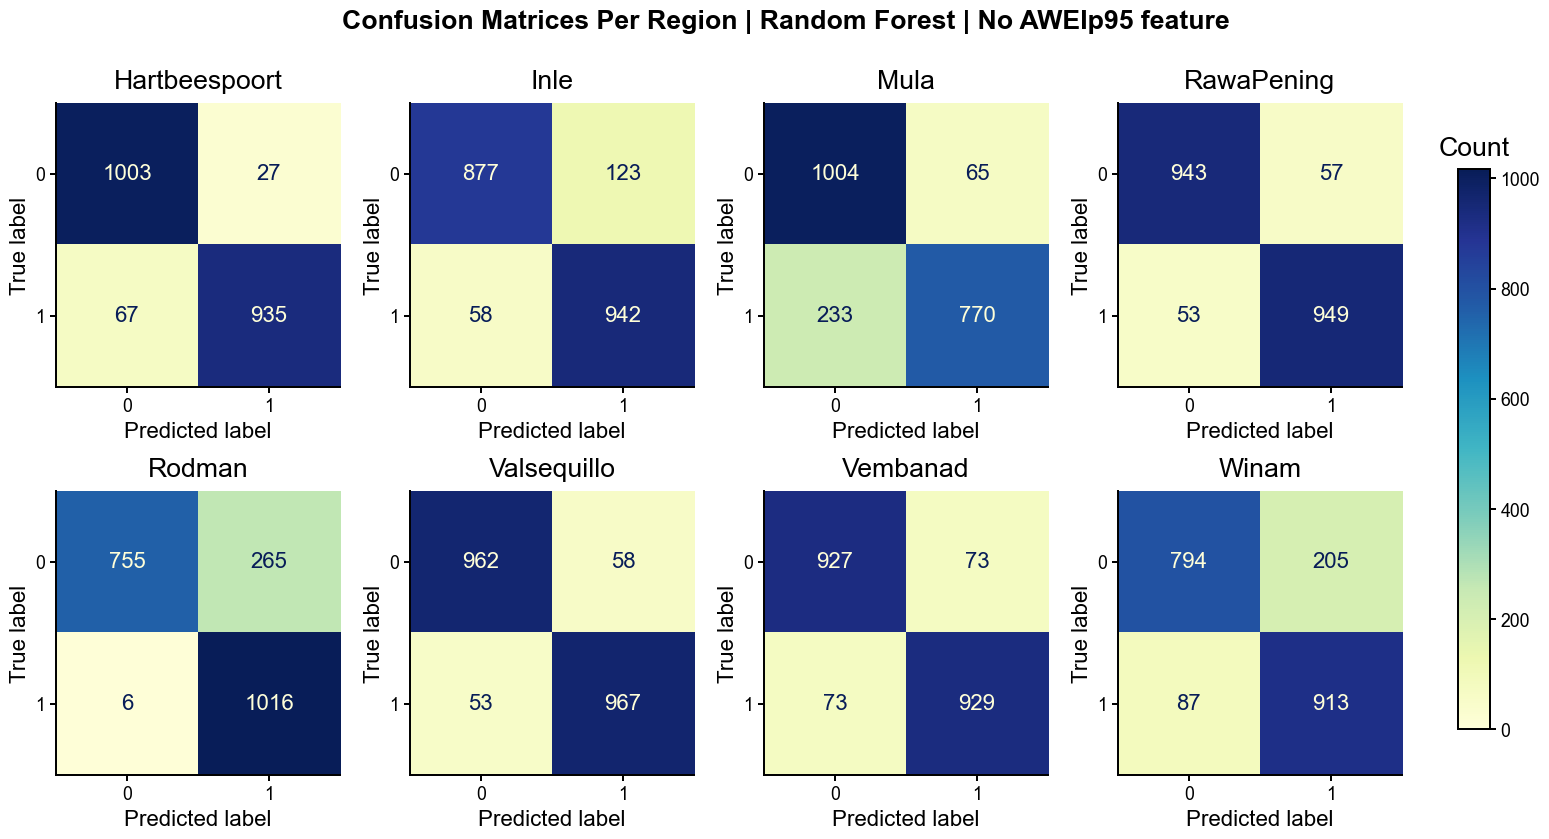

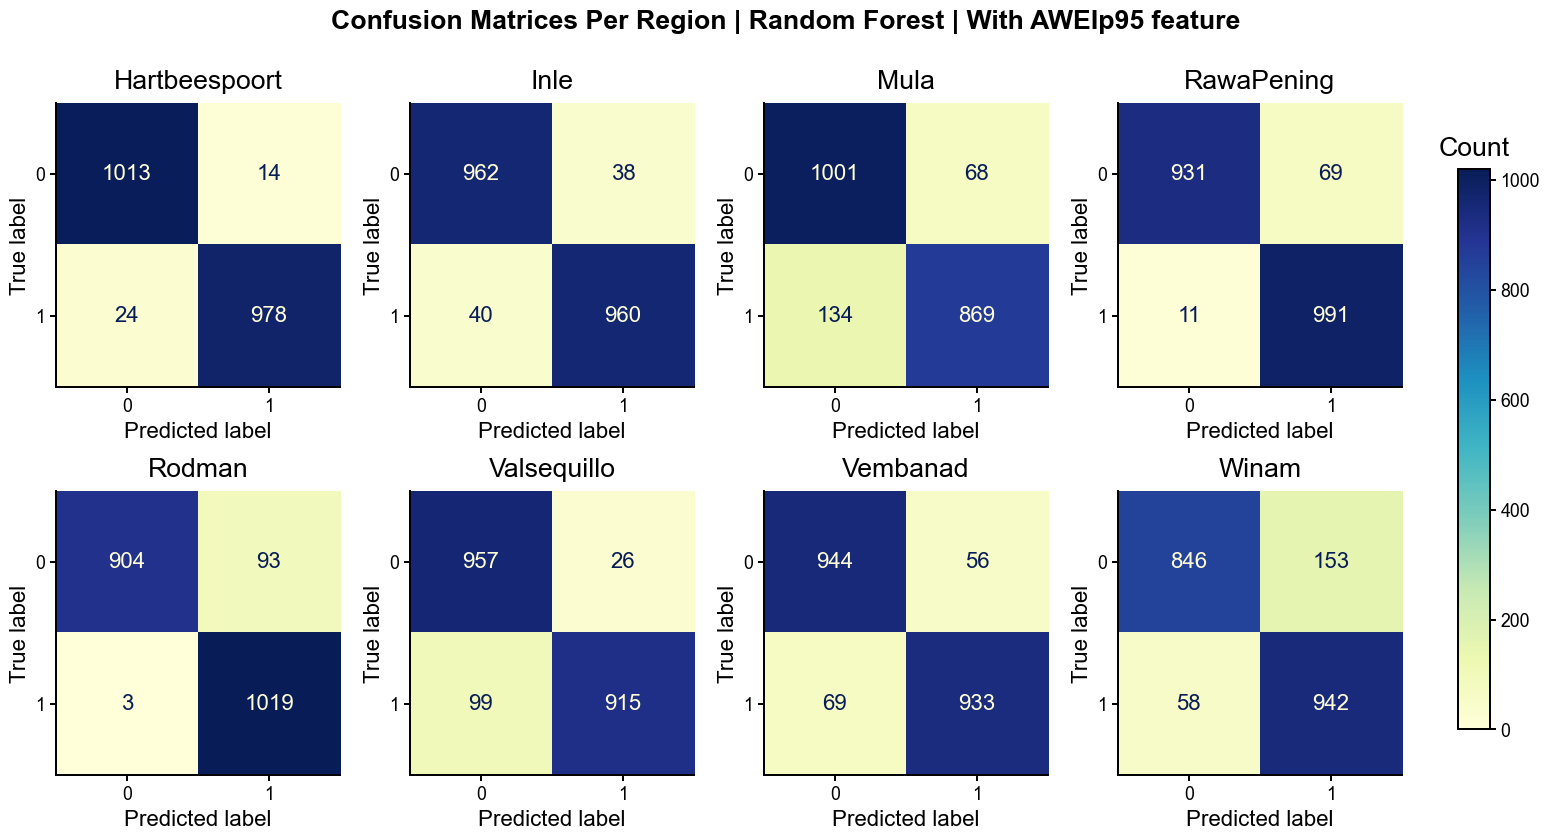

In [165]:
fp7 = PROJECT_ROOT / "outputs/RF_outputs" / "RF_AWEI_False_predictions_.csv"
fp8 = PROJECT_ROOT / "outputs/RF_outputs" / "RF_AWEI_True_predictions_.csv"

model = "Random Forest"

prediction_fp_list = [fp7, fp8]


for fp in prediction_fp_list:

    predictions_df = pd.read_csv(fp)

    AWEIp95 = predictions_df["AWEIp95"][0]
    

    if AWEIp95:
        model_string = f"{model} | With AWEIp95 feature"
    else:
        model_string = f"{model} | No AWEIp95 feature"

    set_pubr_theme(
        base_size= 16
    )

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    # compute a shared color scale so the colorbar is meaningful across panels
    all_cms = []
    groups = list(predictions_df.groupby('location'))
    for _, group in groups:
        all_cms.append(confusion_matrix(group['y_true'], group['y_pred']))
    vmax = max(cm.max() for cm in all_cms)

    disp = None  # keep a reference to use for the colorbar
    for ax, (location, group), cm in zip(axes, groups, all_cms):
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
        disp.plot(ax=ax, cmap = "YlGnBu", colorbar=False, im_kw={'vmin': 0, 'vmax': vmax})
        ax.set_title(location, pad= 10)

    # leave room on the right for the shared colorbar
    fig.tight_layout(rect=[0, 0, 0.9, 1])

    # add one colorbar in a dedicated axes: [left, bottom, width, height] in figure coords
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(disp.im_, cax=cbar_ax)
    cbar_ax.set_title('Count', pad = 10)
    fig.suptitle(f"Confusion Matrices Per Region | {model_string}", y = 1.05)

    save_fp = PROJECT_ROOT / "outputs/plots" / "confusion_matrices" / f"Confusion_matrices_{model_string}.png"

    fig.savefig(save_fp, dpi= 300, bbox_inches = 'tight')
    plt.show()